In [1]:
!pip install Kneed

In [2]:
%pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.


<a id="1"></a>
<div style= "border-radius:10px; border:#787878 solid; padding: 15px; background-color: #E7E5E4; font-size:100%; text-align:left">

<h2 style="color:#0066E1"> ▶️ Introduction </font></h2>

### Dataset: Customer Data

Customer segmentation can help businesses tailor their marketing efforts and improve customer satisfaction. Here’s how
Functionally, customer segmentation involves dividing a customer base into distinct groups or segments—based on shared characteristics and behaviors. By understanding the needs and preferences of each segment, businesses can deliver more personalized and effective marketing campaigns, leading to increased customer retention and revenue.

we’ll explore customer segmentation in Python by combining two fundamental techniques: RFM (Recency, Frequency, Monetary) analysis and K-Means clustering. RFM analysis provides a structured framework for evaluating customer behavior, while K-means clustering offers a data-driven approach to group customers into meaningful segments. We’ll work with a real-world dataset from the retail industry: the Online Retail dataset from UCI machine learning repository..


# Applications of Cluster Analysis:

Cluster analysis has various applications in different fields such as marketing, finance, healthcare, and more. In marketing, businesses can use cluster analysis to group customers with similar characteristics together and create targeted marketing campaigns. In finance, clustering can be used to identify patterns in stock prices and create investment strategies. In healthcare, clustering can be used to identify patient groups with similar symptoms and create personalized treatment plans.

Python and scikit-learn provide a range of clustering algorithms whose use depends on the type of data and the desired outcome. Some popular clustering algorithms include hierarchical clustering, density-based clustering, and partition-based clustering. Each algorithm has its own advantages and disadvantages, and it is important to choose the right algorithm based on the data and the problem at hand.

In addition to clustering algorithms, scikit-learn provides various evaluation metrics to evaluate the performance of clustering algorithms. These metrics include silhouette score, adjusted rand index, and homogeneity score, among others. These metrics can be used to compare different clustering algorithms and choose the one that performs the best for a given dataset.

Moreover, scikit-learn provides various tools for data preprocessing, such as scaling, normalization, and dimensionality reduction. These tools can help in improving the performance of clustering algorithms and reducing the effects of noise and outliers in the data. For instance, scaling and normalization techniques can help in reducing the impact of differences in the scales of the variables on the results of the clustering algorithm.

Furthermore, the combination of cluster analysis with other techniques such as classification and regression can lead to more advanced and sophisticated machine learning models used for a wider range of applications. For instance, in healthcare, classification models can be built using clusters identified by the clustering algorithm to predict the likelihood of a patient developing a certain disease. In finance, regression models can be built to predict stock prices based on the patterns identified by the clustering algorithm.

As such, cluster analysis is a valuable tool for any data scientist or machine learning practitioner to have in their toolbox. It can help in gaining valuable insights from data and making informed decisions in various fields. However, it is important to choose the right algorithm and evaluation metric based on the data and the problem at hand to obtain accurate and meaningful results.

In conclusion, cluster analysis is a powerful technique that allows us to group similar data points into distinct categories, enabling the extraction of valuable insights and informed decision-making in various fields. It serves as an essential tool for data scientists, helping uncover hidden patterns and structures within datasets. By employing cluster analysis, we can gain a deeper understanding of our data and unlock its potential for driving impactful outcomes.


### Content

The dataset includes shopping information whose various variables are shown in the following table:
The dataset contains 18 columns in customer_shopping_data.csv..

<table style="width:100%">
<thead>
<tr>
<th style="text-align:center; font-weight: bold; font-size:20px">Variable Name</th>
<th style="text-align:center; font-weight: bold; font-size:20px">Description</th>
</tr>
</thead>
<tbody>
<tr>
<td><b>BALANCE</b></td>
<td>تعادل خرید</td>
</tr>
<tr>
<td><b>BALANCE_FREQUENCY </b></td>
<td>  دفعات تعادل خرید</td>
</tr>
<tr>
 <tr style="background-color:gold; color: black;">
<td><b>PURCHASES</b></td>
<td><br> خرید </td>
</tr>
<tr>
<td><b>ONEOFF_PURCHASES</b></td>
<td> خرید های یکباره</td>
</tr>
<tr>
<td><b>INSTALLMENTS_PURCHASES</b></td>
<td>خرید اقساطی</td>
</tr>
<tr>
<td><b>CASH_ADVANCE</b></td>
<td> پیش پرداخت نقدی </td>
</tr>
<tr>
<td><b>PURCHASES_FREQUENCY</b></td>
<td> تعداد دفعات خرید </td>
</tr>
<tr>
<td><b>ONEOFF_PURCHASES_FREQUENCY</b></td>
<td> تعداد دفعات خرید یکباره </td>
</tr>
<tr>       
<td><b>PURCHASES_INSTALLMENTS_FREQUENCY</b></td>
<td> دفعات خرید اقساطی</td>
</tr>
<tr>
<td><b>CASH_ADVANCE_FREQUENCY</b></td>
<td> دفعات پیش پرداخت نقدی </td>
</tr>
<tr>    
<td><b>CASH_ADVANCE_TRX</b></td>
<td> پیش پرداخت نقدی TRX </td>
</tr>
<tr>
<td><b>PURCHASES_TRX</b></td>
<td> خرید TRX</td>
</tr>
<td><b>CREDIT_LIMIT</b></td>
<td> محدودیت اعتبار </td>
<tr>
<td><b>PAYMENTS</b></td>
<td>مبلغ پرداختی</td>
</tr>
<tr>
<td><b>MINIMUM_PAYMENTS</b></td>
<td>حداقل مبلغ پرداختی</td>
</tr>
<tr>
<td><b>PRC_FULL_PAYMENT</b></td>
<td>  پرداخت کامل کمیسیون </td>
</tr>
<tr>    
<td><b>TENURE</b></td>
<td>نگهداری حساب از منظر بازرسی حساب و کتاب</td>
</tr>    
</tbody>
</table>

In [3]:
# Import requierment libarary
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import plotly
import plotly.express as px
from plotly.offline import iplot, init_notebook_mode
init_notebook_mode(connected = True)
import plotly.graph_objs as go
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn import preprocessing
from sklearn.metrics import classification_report, confusion_matrix 
from sklearn.metrics import jaccard_score
from sklearn.metrics import precision_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.datasets import make_blobs
import tkinter as tk
from matplotlib.backends.backend_tkagg import ( FigureCanvasTkAgg, NavigationToolbar2Tk)
from tkinter import filedialog
color_list = sns.color_palette(['#F2AFEF', '#C499F3', '#7360DF', '#33186B', '#711DB0', '#C21292', '#EF4040', '#FFA732'])

In [4]:
# Import data
data=pd.read_csv("/kaggle/input/customer-data-clustring/Customer-Data - 2.csv")

In [5]:
# Overview from dataframe
df = pd.DataFrame(data)
df_rows_count, df_columns_count = df.shape
print(f'number of samples: {df_rows_count}')
print(f'number of columns: {df_columns_count}')
df.head(7)

number of samples: 8950
number of columns: 18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
5,C10006,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12
6,C10007,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12


In [6]:
# Data profilling
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [7]:
#convert columns with int values to float
df['CASH_ADVANCE_TRX'] = df['CASH_ADVANCE_TRX'].astype(float)
df['PURCHASES_TRX'] = df['PURCHASES_TRX'].astype(float)
df['TENURE'] = df['TENURE'].astype(float)

In [8]:
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

<h3 align="left"><font color='#E83500'>💡 Note:</font></h3>

According to the above information, it is clear that we see missing values in two columns CREDIT_LIMIT and MINIMUM_PAYMENTS. You can remove those values or replace them with suitable values. Considering the value of the data, it is better to use the placement method..We will continue this placement.

In [9]:
# Separate object and float columns and describe both of them
df_num = df.select_dtypes(['float64'])
df_obj = df.select_dtypes(['object'])

In [10]:
df_num.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204822,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634780,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [11]:
df_obj.describe()

,CUST_ID
count,8950
unique,8950
top,C10001
freq,1


In [12]:
#delete CUST _ID column
df1 = df.drop("CUST_ID", axis='columns')

<h3 align="left"><font color='#C499F3'>💡 Note:</font></h3>

1.Mean imputation can be used when the distribution of the data is normal,Median imputation is appropriate when the distribution of the data is skewed. 

2.In the following, it can be seen that in the analysis of graphs related to features, the graphs or in other words their distribution of data is skewed.  Therefore, we use the median to fill in the missing values..

In [13]:
#Replace missing values with the median of each column
df1['CREDIT_LIMIT'] = df1['CREDIT_LIMIT'].fillna(df1['CREDIT_LIMIT'].median())
df1['MINIMUM_PAYMENTS'] = df1['MINIMUM_PAYMENTS'].fillna(df1['MINIMUM_PAYMENTS'].median())

In [14]:
df1.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0


# Data visualisation

## Heatmap of Correlations:

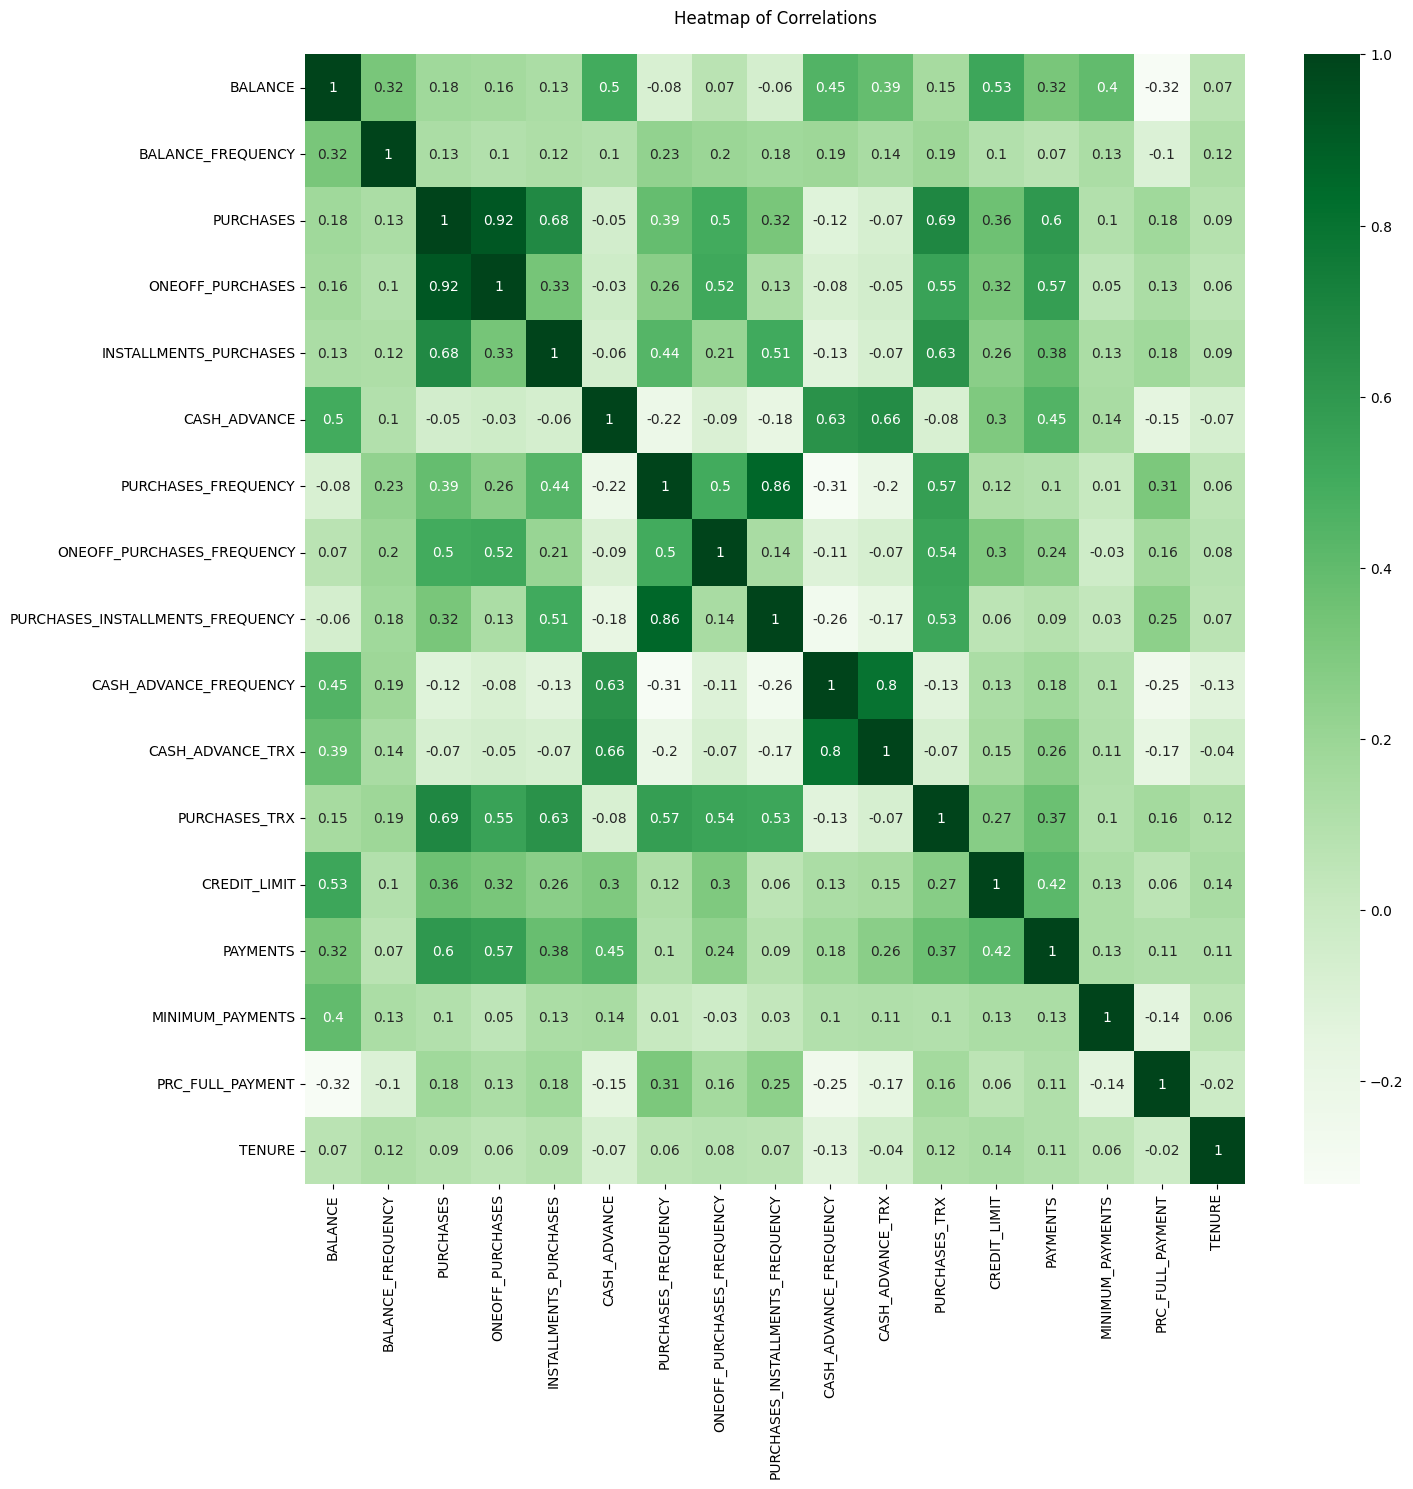

In [15]:
plt.figure(figsize=(15,15))
sns.heatmap(round(df1.corr(),2), cmap='Greens', annot=True)
plt.title('Heatmap of Correlations', y=1.02)
plt.tight_layout()
plt.show()

1.According to the above diagram, it is clear that two features PURCHASES and ONEOFF_PURCHASES have a high correlation with each other(0.92)..

2.Two columns PURCHASES_FREQUENCY and PURCHASES_INSTALLMENTS_FREQUENCY also have a correlation of 0.86..

3.Two columns CASH_ADVANCE_FREQUENCY and CASH_ADVANCE_TRX also have a correlation of 0.80..

4.Other features and their correlation with each other can be interpreted and checked..

## Scatter plots for Some features:

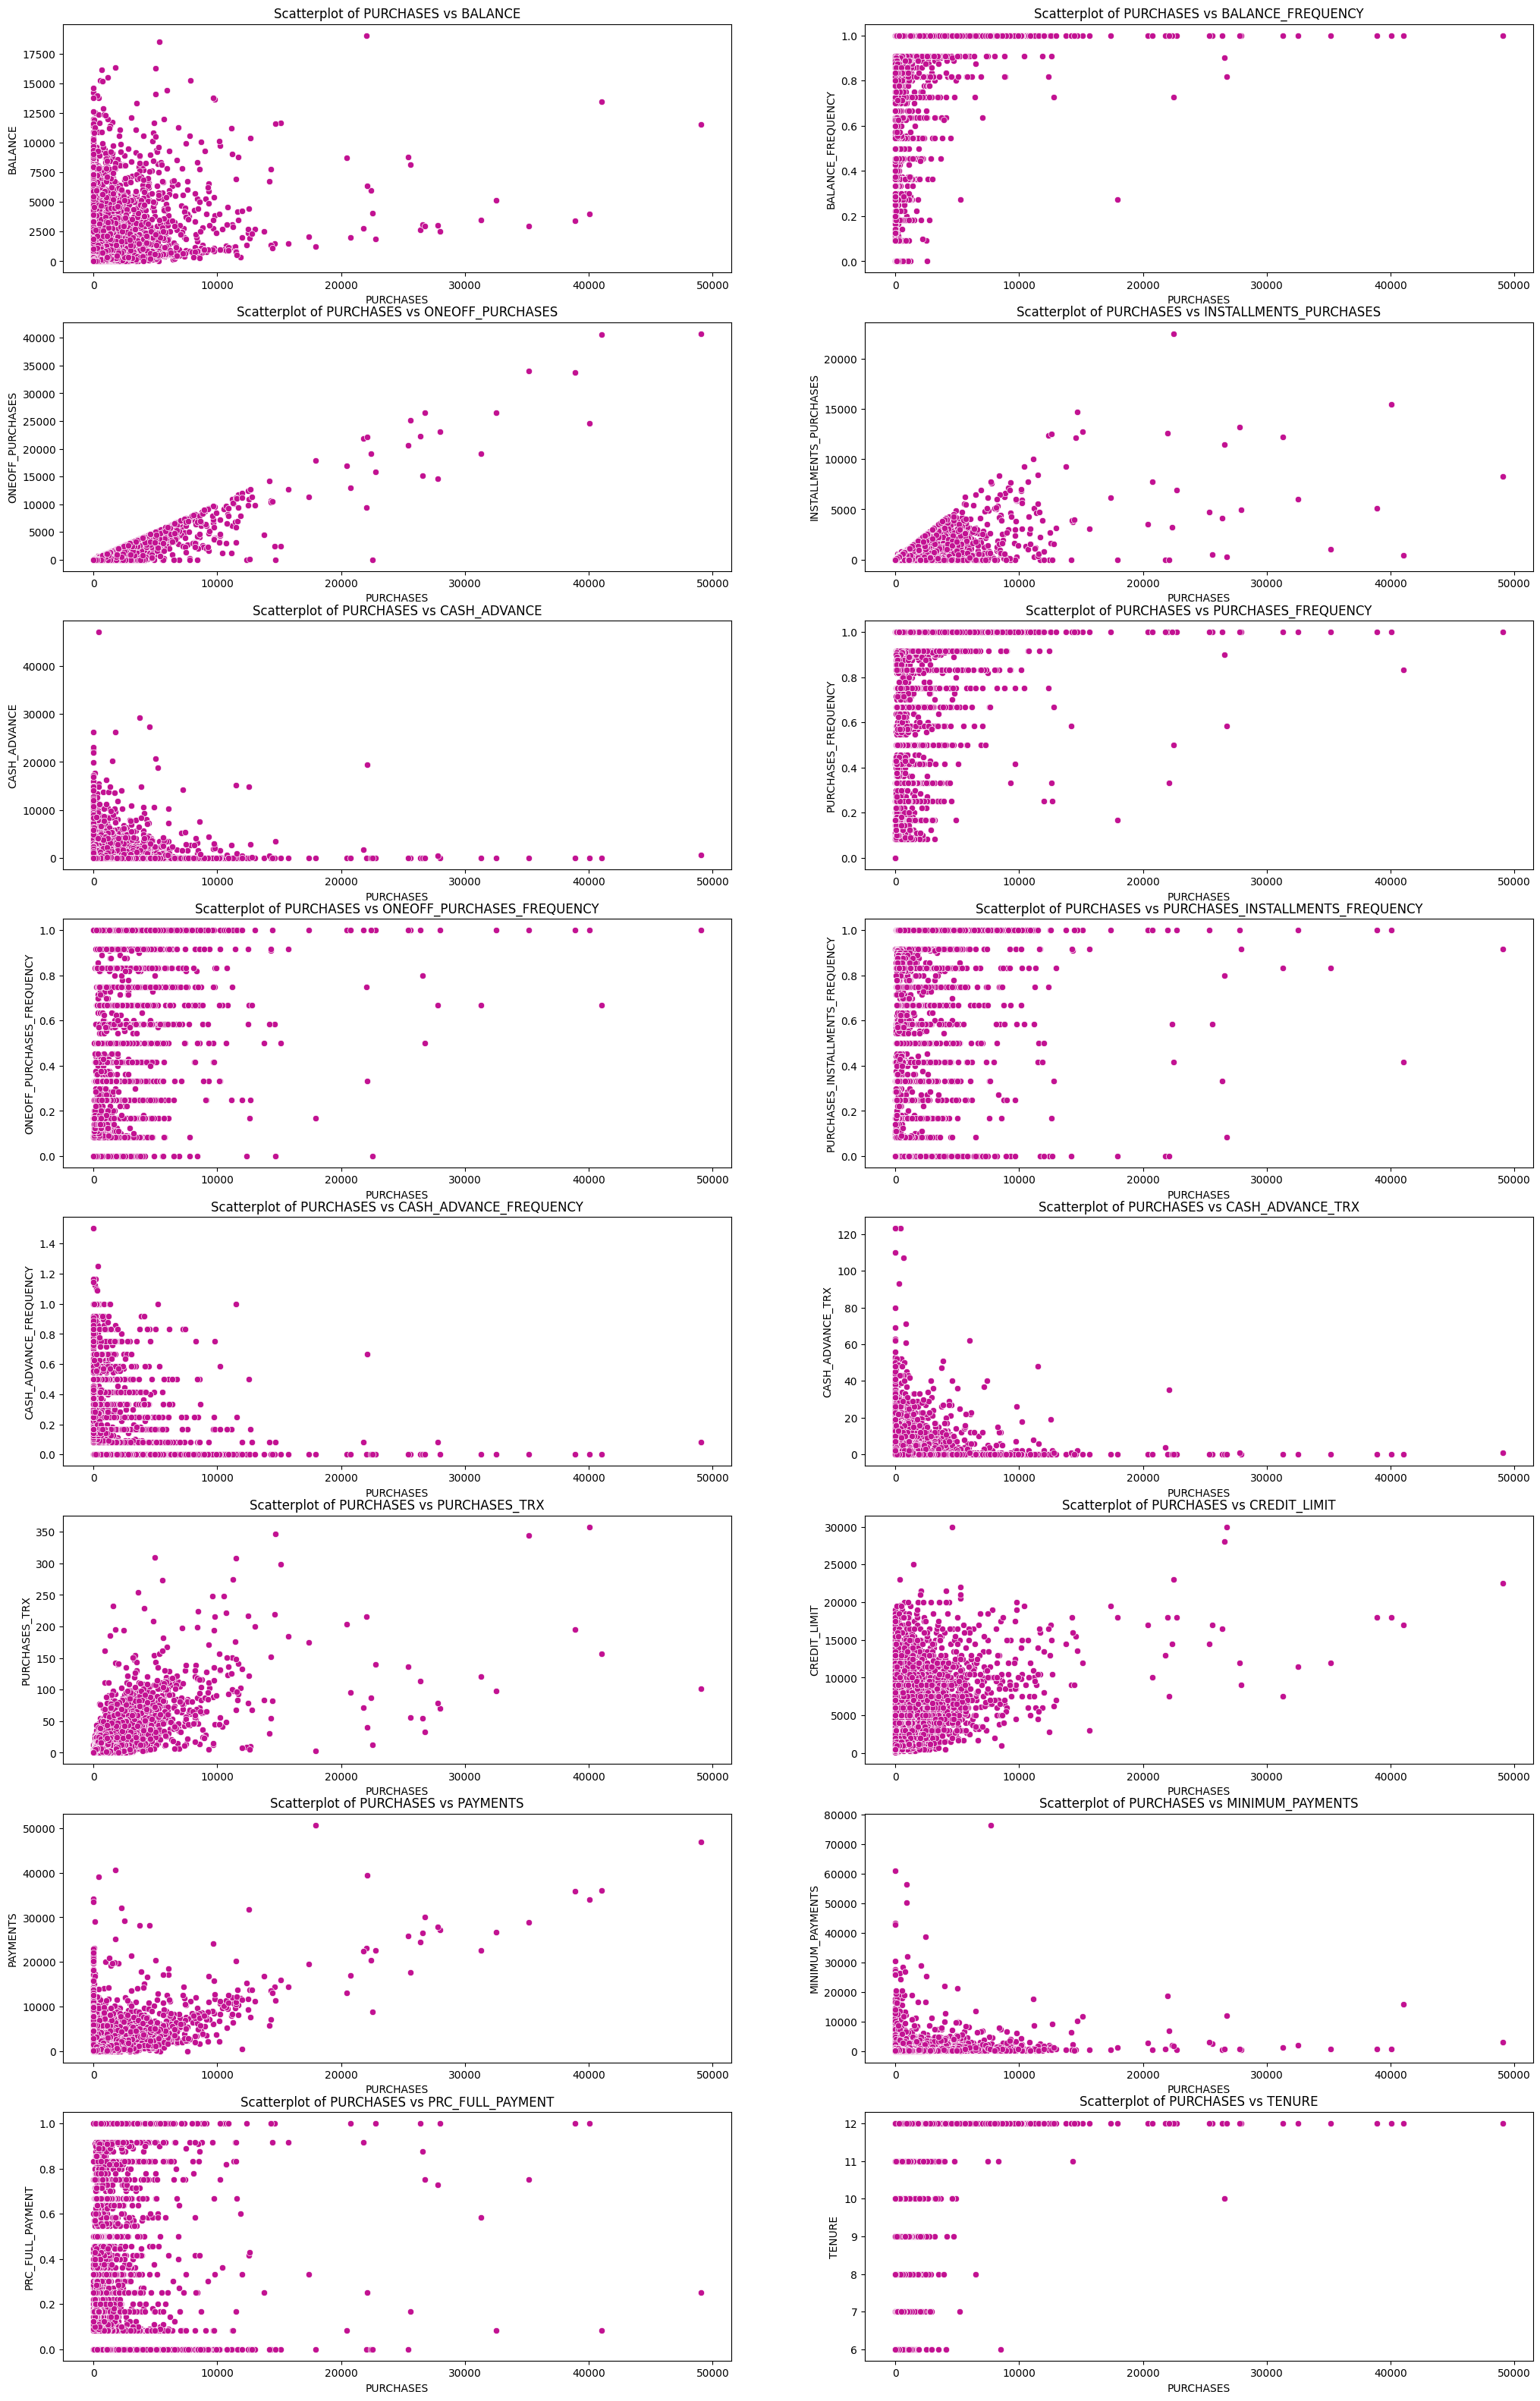

In [16]:
columns1=['BALANCE', 'BALANCE_FREQUENCY', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY','CASH_ADVANCE_FREQUENCY','CASH_ADVANCE_TRX','PURCHASES_TRX','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS','PRC_FULL_PAYMENT','TENURE']
fig, ax = plt.subplots(8,2,figsize=(25,40))
column2 = columns1.copy()
for i, col in enumerate(column2):
    sns.scatterplot(data=df1, x='PURCHASES', y=col,  ax=ax[i//2, i%2],  color=color_list[5])
    ax[i//2, i%2].set_title(f'Scatterplot of PURCHASES vs {col}')
plt.show()

# Interpretations:

<div style="background-color: white; color: black">

 ✅  First of all, it should be noted that in all the above scatter plots, the x-axis shows the purchase values ​​and the y-axis variably shows the relationship of other features with the x-axis, which we will interpret..
 
 The graphs are examined from the first row and from left to right..

1.In the first graph, which shows the purchase and balance, the accumulation of data in the range, x=[0,10000] y=[0,15000] is more than other points,In fact, the heart of the data in this scatter plot is located in this interval. Other data can be seen sporadicall..

      
2.In the second graph, where the y-axis represents BALANCE_FREQUENCY, it is clear that the accumulation of data occurs mostly in purchases of less than 5000.

The value of BALANCE_FREQUENCY varies between 0 and 1, although most samples are observed in BALANCE_FREQUENCY between [0.1,0.9]. In BALANCE_FREQUENCY=1, some data can be seen in which the amount of PURCHASES is upward..


3.The next chart shows the relationship between PURCHASES and ONEOFF_PURCHASES, and as we have seen before, they are highly correlated with each other. There is a linear relationship between them..

On the other hand, the accumulation of data in x=[0,15000], y=[0,15000] range is more. And some data can be seen in a scattered manner..

4.In the case of the next graph, which shows the relationship between PURCHASES and INSTALLMENTS_PURCHASES, there is a linear relationship. The accumulation of data in the range of x=[0,12000] , y=[0,12000] is more than other parts..

5.The next diagram shows the relationship between PURCHASES and CASH_ADVANCE, which includes the most samples in [x,y]=[15000,15000] range. A number of outliers (or noise) are also observed that should be investigated...


6.Charts 6, 7, and 8, which show the relationship between purchases and PURCHASES_FREQUENCY, ONEOFF_PURCHASES_FREQUENCY, and PURCHASES_INSTALLMENTS_FREQUENCY, can be interpreted almost similarly..

In these graphs, the y-axis varies between 0 and 1. The accumulation of samples is mostly in the interval x less than 10000..

7.PURCHASES charts against  CASH_ADVANCE_TRX, PURCHASES_TRX , CREDIT_LIMIT, PAYMENTS and MINIMUM_PAYMENT can also be interpreted in almost the same way. In this way, the accumulation of data is in a certain range and outliers are visible and of interest..

# Box Plots:

BALANCE: 


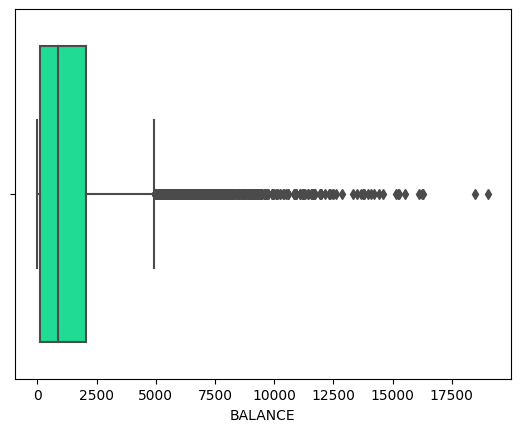

BALANCE_FREQUENCY: 


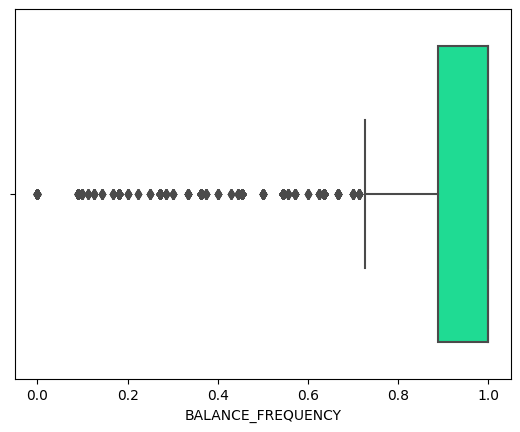

PURCHASES: 


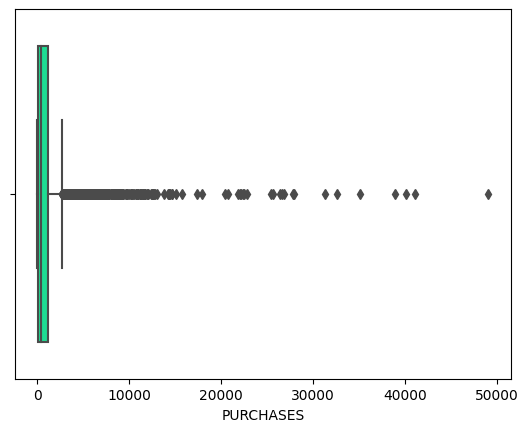

ONEOFF_PURCHASES: 


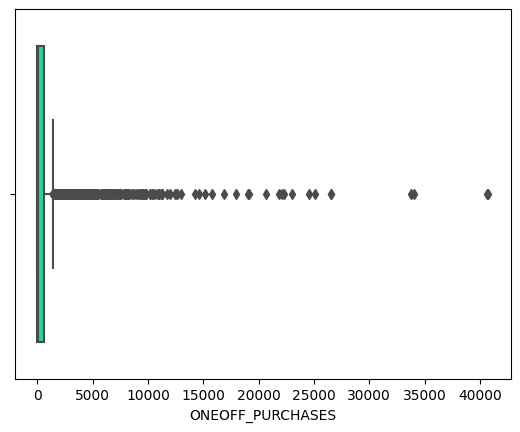

INSTALLMENTS_PURCHASES: 


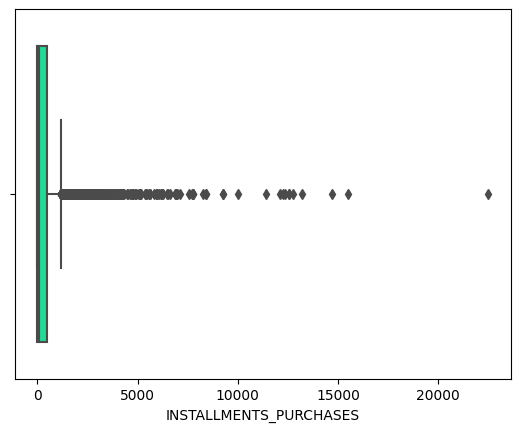

CASH_ADVANCE: 


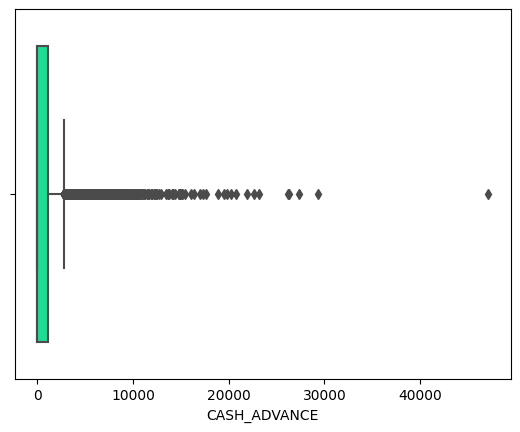

PURCHASES_FREQUENCY: 


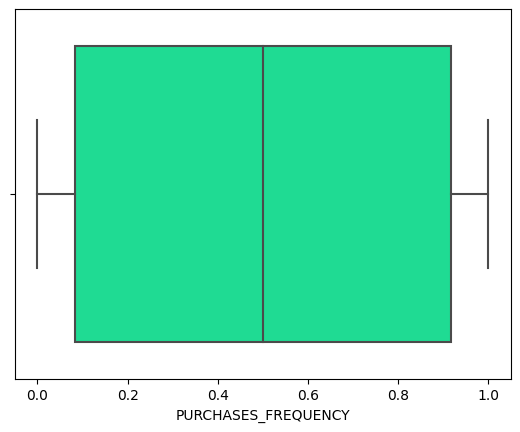

ONEOFF_PURCHASES_FREQUENCY: 


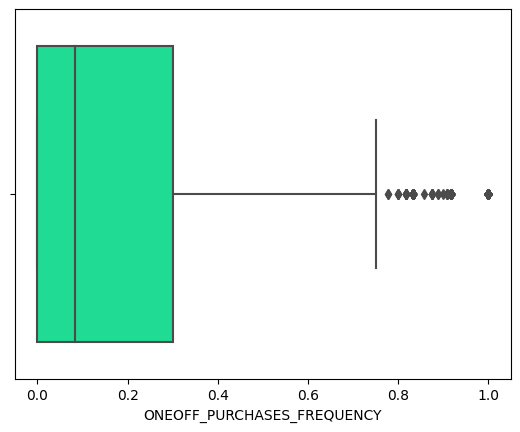

PURCHASES_INSTALLMENTS_FREQUENCY: 


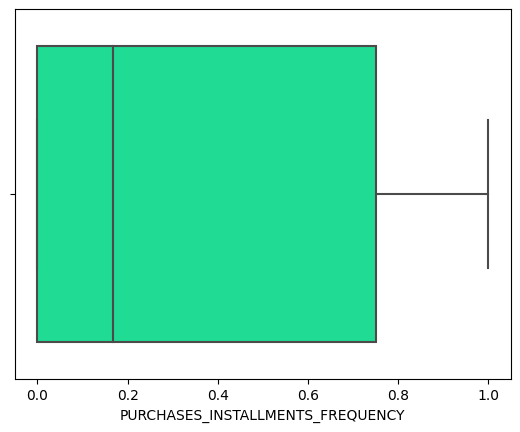

CASH_ADVANCE_FREQUENCY: 


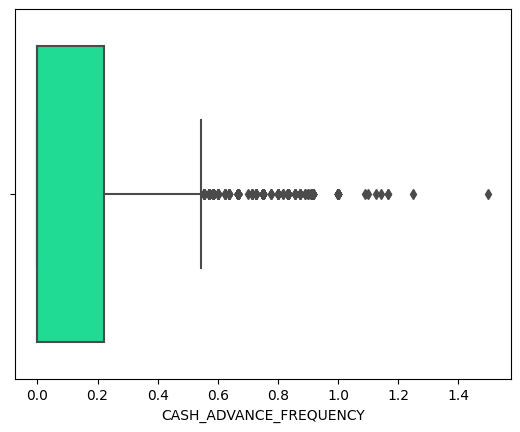

CASH_ADVANCE_TRX: 


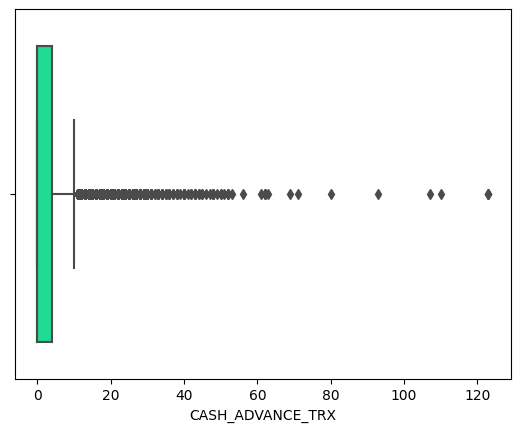

PURCHASES_TRX: 


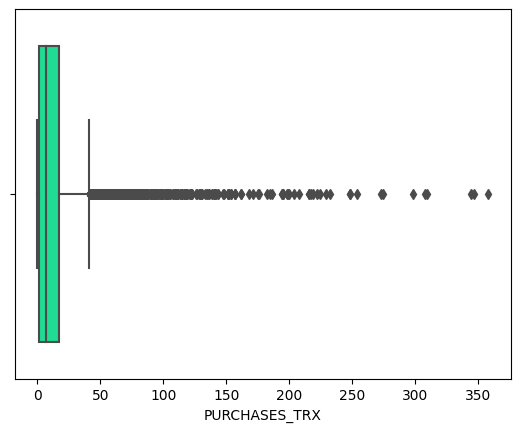

CREDIT_LIMIT: 


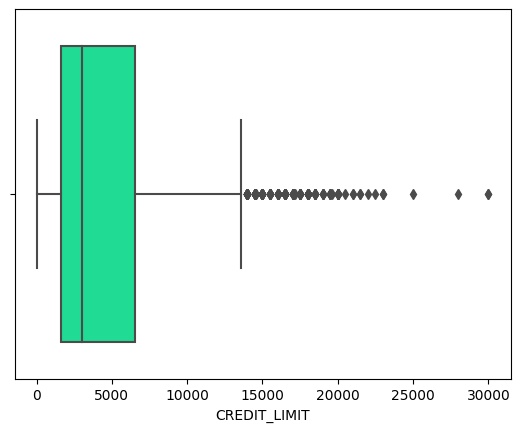

PAYMENTS: 


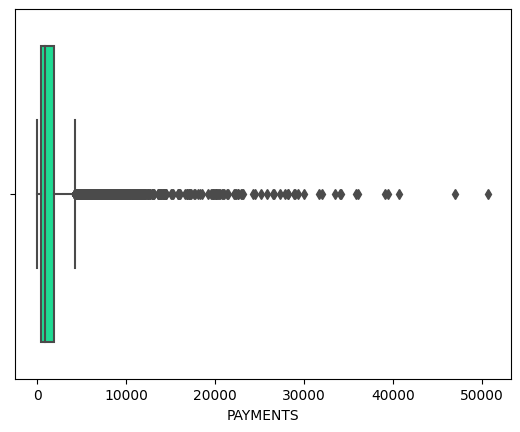

MINIMUM_PAYMENTS: 


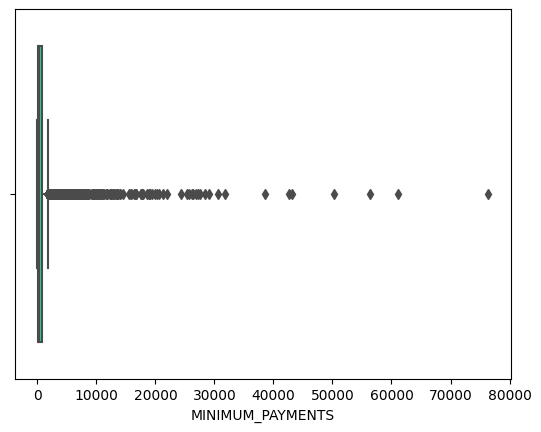

PRC_FULL_PAYMENT: 


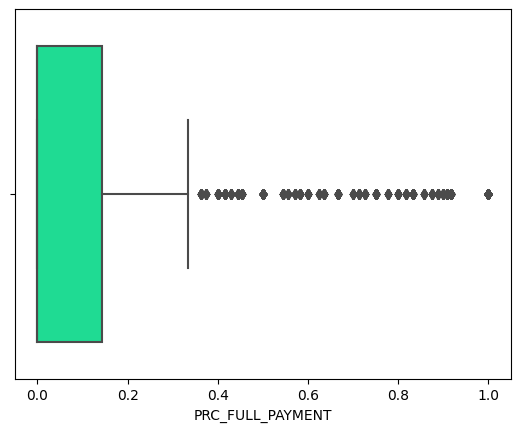

TENURE: 


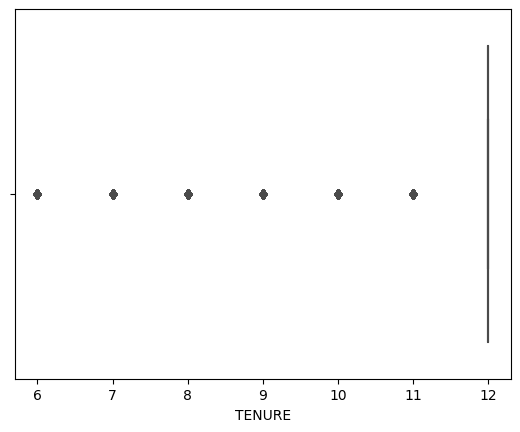

In [17]:
list1 = ['BALANCE','BALANCE_FREQUENCY','PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES','CASH_ADVANCE','PURCHASES_FREQUENCY','ONEOFF_PURCHASES_FREQUENCY','PURCHASES_INSTALLMENTS_FREQUENCY','CASH_ADVANCE_FREQUENCY' ,'CASH_ADVANCE_TRX','PURCHASES_TRX','CREDIT_LIMIT','PAYMENTS','MINIMUM_PAYMENTS','PRC_FULL_PAYMENT','TENURE']
for i in list1:
    print(str(i)+': ')
    ax = sns.boxplot(x=df1[str(i)],color='mediumspringgreen')
    plt.show()


By examining the above box plots, it seems that the following two data with specified indices are considered noise and maybe their presence in the dataset will not have a good effect on the final clustering..

In [18]:
print((df1['CASH_ADVANCE']>40000))

0       False
1       False
2       False
3       False
4       False
        ...  
8945    False
8946    False
8947    False
8948    False
8949    False
Name: CASH_ADVANCE, Length: 8950, dtype: bool


In [19]:
print(df1[(df1['CASH_ADVANCE']>40000)])

          BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
2159  10905.05381                1.0     431.93             133.5   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
2159                  298.43   47137.21176             0.583333   

      ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
2159                        0.25                               0.5   

      CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  CREDIT_LIMIT  \
2159                     1.0             123.0           21.0       19600.0   

         PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  TENURE  
2159  39048.59762       5394.173671               0.0    12.0  


In [20]:
print((df1['INSTALLMENTS_PURCHASES']>20000))

0       False
1       False
2       False
3       False
4       False
        ...  
8945    False
8946    False
8947    False
8948    False
8949    False
Name: INSTALLMENTS_PURCHASES, Length: 8950, dtype: bool


In [21]:
print(df1[(df1['INSTALLMENTS_PURCHASES']>20000)])

          BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
5260  4060.710208           0.727273    22500.0               0.0   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
5260                 22500.0           0.0                  0.5   

      ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
5260                         0.0                          0.416667   

      CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  CREDIT_LIMIT  \
5260                     0.0               0.0           12.0       23000.0   

         PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  TENURE  
5260  8760.860264       1645.535202               0.0    12.0  


In [22]:
df2=df1.drop(index=[2159,5260])

In [23]:
df2 = df2.sort_index()

# Histogram of all features:

array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES'}>],
       [<Axes: title={'center': 'ONEOFF_PURCHASES'}>,
        <Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>],
       [<Axes: title={'center': 'PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>],
       [<Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'PURCHASES_TRX'}>],
       [<Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>],
       [<Axes: title={'center': 'PRC_FULL_PAYMENT'}>,
        <Axes: title={'center': 'TENURE'}>, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <A

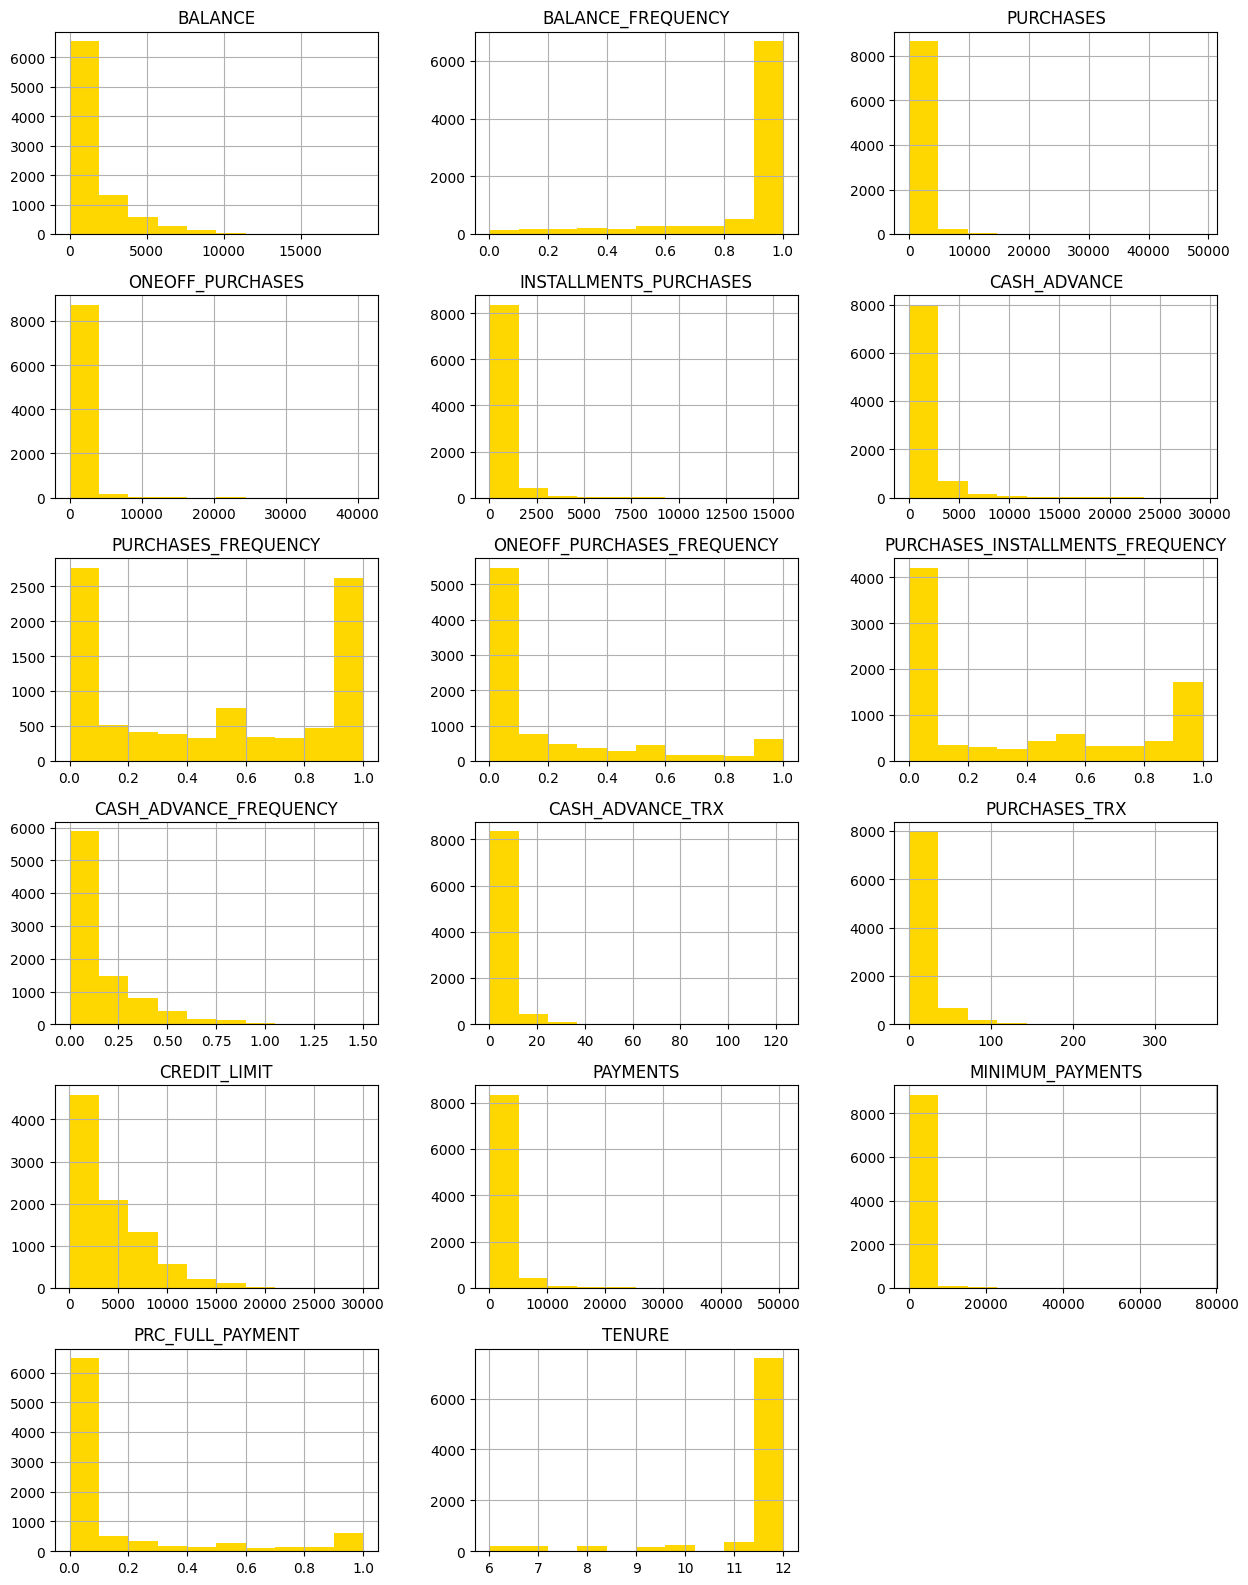

In [24]:
df2.hist(figsize=(15,30),layout=(9,3) , color='gold')

<h3 align="left"><font color='#E83500'>💡 Note:</font></h3>

1.According to the above hisograms, it can be seen that for many features (almost 13), have right-skewed distribution

2.Features like BALANCE_FREQUENCY and TENURE have left-skewed distribution..
 
3.Features like PURCHASES_FREQUENCY and PURCHASES_INSTALLMENTS_FREQUENCY first increase and decrease when moving to the right, then begin to increase again with a slight fluctuation at the end..

## The final dataset for clustering:

In [25]:
df2

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,325.594462,48.886365,0.500000,6.0
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,275.861322,312.343947,0.000000,6.0
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0.0,5.0,1000.0,81.270775,82.418369,0.250000,6.0
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2.0,0.0,500.0,52.549959,55.755628,0.250000,6.0


# Normalize:

In [26]:
#define scaler and Scaled_features
Scaler=StandardScaler()
Scaled_features=Scaler.fit_transform(df2)

In [27]:
kmeans_set={"init":"random", "n_init":10 , "max_iter":300 , "random_state":42}

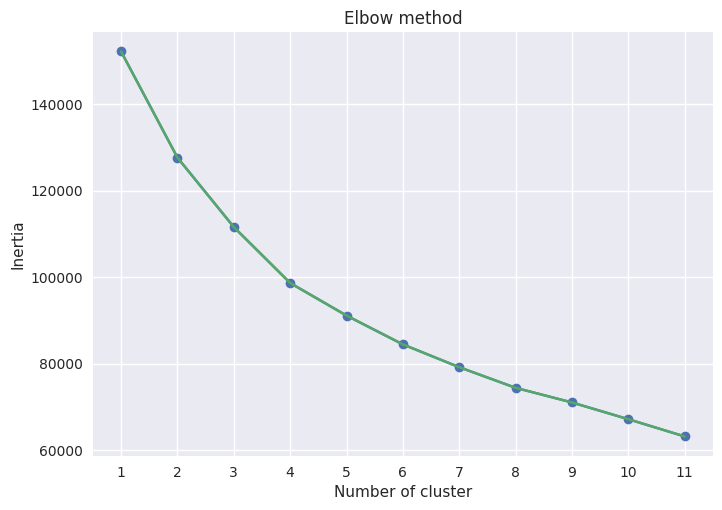

In [28]:
#using Elbow method to show Number of cluster and Inertia
List=[]
for k in range(1,12):
    kmeans=KMeans(n_clusters=k , **kmeans_set)
    kmeans.fit(Scaled_features)
    List.append(kmeans.inertia_)
plt.style.use("seaborn-v0_8")  
plt.plot(range(1,12), List, marker='o')
plt.plot(range(1,12), List)
plt.xticks(range(1,12))
plt.xlabel("Number of cluster")
plt.ylabel("Inertia")
plt.title('Elbow method')
plt.show()

In [29]:
#Finding the optimal cluster
k1=KneeLocator(range(1,12), List, curve="convex" , direction="decreasing")
k1.elbow

4

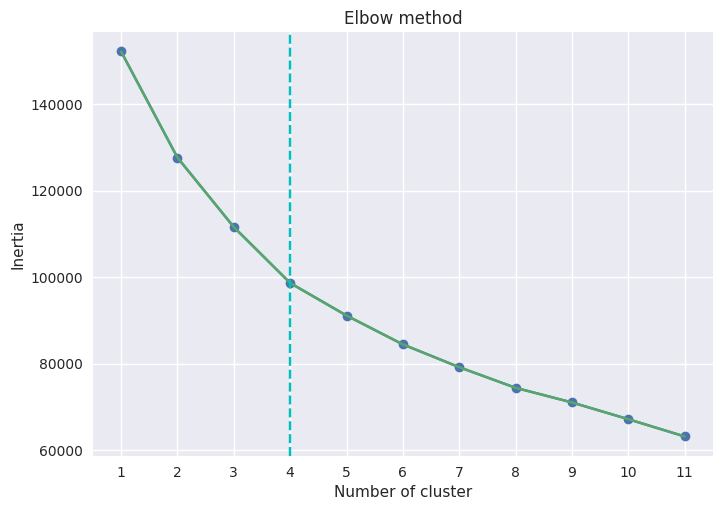

In [30]:
List=[]
for k in range(1,12):
    kmeans=KMeans(n_clusters=k , **kmeans_set)
    kmeans.fit(Scaled_features)
    List.append(kmeans.inertia_)
plt.style.use("seaborn-v0_8")  
#plt.style.use("five thirtyeight")
plt.plot(range(1,12), List, marker='o')
plt.plot(range(1,12), List)
plt.xticks(range(1,12))
plt.xlabel("Number of cluster")
plt.ylabel("Inertia")
plt.title('Elbow method')
plt.axvline(x=k1.elbow , color='c', label= "axvline_fullheight" , ls='--')
plt.show()

In [31]:
#show cluster_centers
import warnings
warnings.filterwarnings("ignore")
kmeans=KMeans(n_clusters=4).fit(df2)
centroids=kmeans.cluster_centers_
print(centroids)

[[8.16339895e+02 8.51926892e-01 5.29698740e+02 2.62967931e+02
  2.67016650e+02 4.93142214e+02 4.54158324e-01 1.35002807e-01
  3.47915368e-01 1.09384697e-01 2.29864889e+00 9.75943148e+00
  2.29856768e+03 9.29720014e+02 5.91035059e+02 1.48206424e-01
  1.13921741e+01]
 [5.91799870e+03 9.57520949e-01 2.64852087e+03 1.62941352e+03
  1.01924131e+03 4.63429002e+03 5.29716527e-01 3.14797861e-01
  4.13649854e-01 3.30656008e-01 1.05843373e+01 3.39548193e+01
  1.10480490e+04 6.74839378e+03 3.26348392e+03 1.05731831e-01
  1.17469880e+01]
 [5.40533094e+03 9.57954542e-01 2.72763638e+04 2.18771029e+04
  5.39926083e+03 1.55037839e+03 9.09027750e-01 8.42361167e-01
  7.20833292e-01 5.90277500e-02 2.50000000e+00 1.27958333e+02
  1.60833333e+04 2.79256345e+04 3.26667104e+03 5.11205792e-01
  1.19166667e+01]
 [2.05993120e+03 9.12116182e-01 1.37592640e+03 8.57690621e+02
  5.18614061e+02 1.08901371e+03 5.56718995e-01 3.17502078e-01
  3.85030985e-01 1.42204197e-01 3.42288169e+00 1.96735650e+01
  7.55946363e+03

In [32]:
#instantiate the k-means class, using optimal number of clusters
kmeans = KMeans(init="random", n_clusters=4, n_init=10, random_state=1)

#fit k-means algorithm to data
kmeans.fit(Scaled_features)

#view cluster assignments for each observation
kmeans.labels_ 

array([2, 1, 3, ..., 3, 2, 2], dtype=int32)

In [33]:
#view cluster assignments for each observation(in dataframe form)
labels=pd.DataFrame(kmeans.labels_)
labels

,0
0,2
1,1
2,3
3,2
4,2
...,...
8943,3
8944,3
8945,3
8946,2


## Adding cluster assignment to df2:

In [34]:
#append cluster assingments to original DataFrame
df2['cluster'] = kmeans.labels_ 
#view updated DataFrame
df2_c=pd.DataFrame(df2)
df2_c

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,2
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,1
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,3
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0,2
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,325.594462,48.886365,0.500000,6.0,3
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,275.861322,312.343947,0.000000,6.0,3
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0.0,5.0,1000.0,81.270775,82.418369,0.250000,6.0,3
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2.0,0.0,500.0,52.549959,55.755628,0.250000,6.0,2


In [35]:
#Checking whether the value of nan exists in different columns of the new dataset
df2_c.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
cluster                             0
dtype: int64

In [36]:
#useing loop for show Number of cluster and silhouette_coefficients
silhouette_coefficients=[]
for k in range(2,12):
    kmeans=KMeans(n_clusters=k, **kmeans_set)
    kmeans.fit(Scaled_features)
    score=silhouette_score(Scaled_features, kmeans.labels_)
    silhouette_coefficients.append(score)

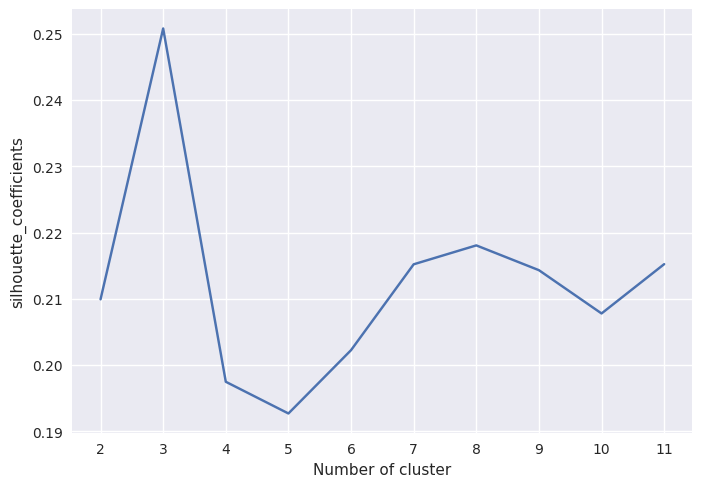

In [37]:
#showing plot related Number of cluster and silhouette_coefficients
plt.style.use("seaborn-v0_8")  
plt.plot(range(2,12), silhouette_coefficients)
plt.xticks(range(2,12))
plt.xlabel("Number of cluster")
plt.ylabel("silhouette_coefficients")
plt.show()

## To indentify which variables are the characteristics of each clusters:

In [38]:
# Analyze the clusters
cluster_analysis = df2_c.groupby('cluster').mean()


# Print the cluster analysis results
print(cluster_analysis)

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
cluster                                                                  
0        3549.313756           0.987545  7635.819976       5096.270024   
1        4553.003152           0.968574   497.154894        318.218241   
2        1000.121435           0.788050   273.501862        211.657312   
3         896.237915           0.936919  1240.787927        595.769910   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
cluster                                                              
0                   2541.016944    659.915716             0.947436   
1                    179.019853   4452.155236             0.284808   
2                     62.111062    580.165354             0.174310   
3                    645.295029    207.603135             0.887359   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
cluster                                                      

# Several plots for Clusters:

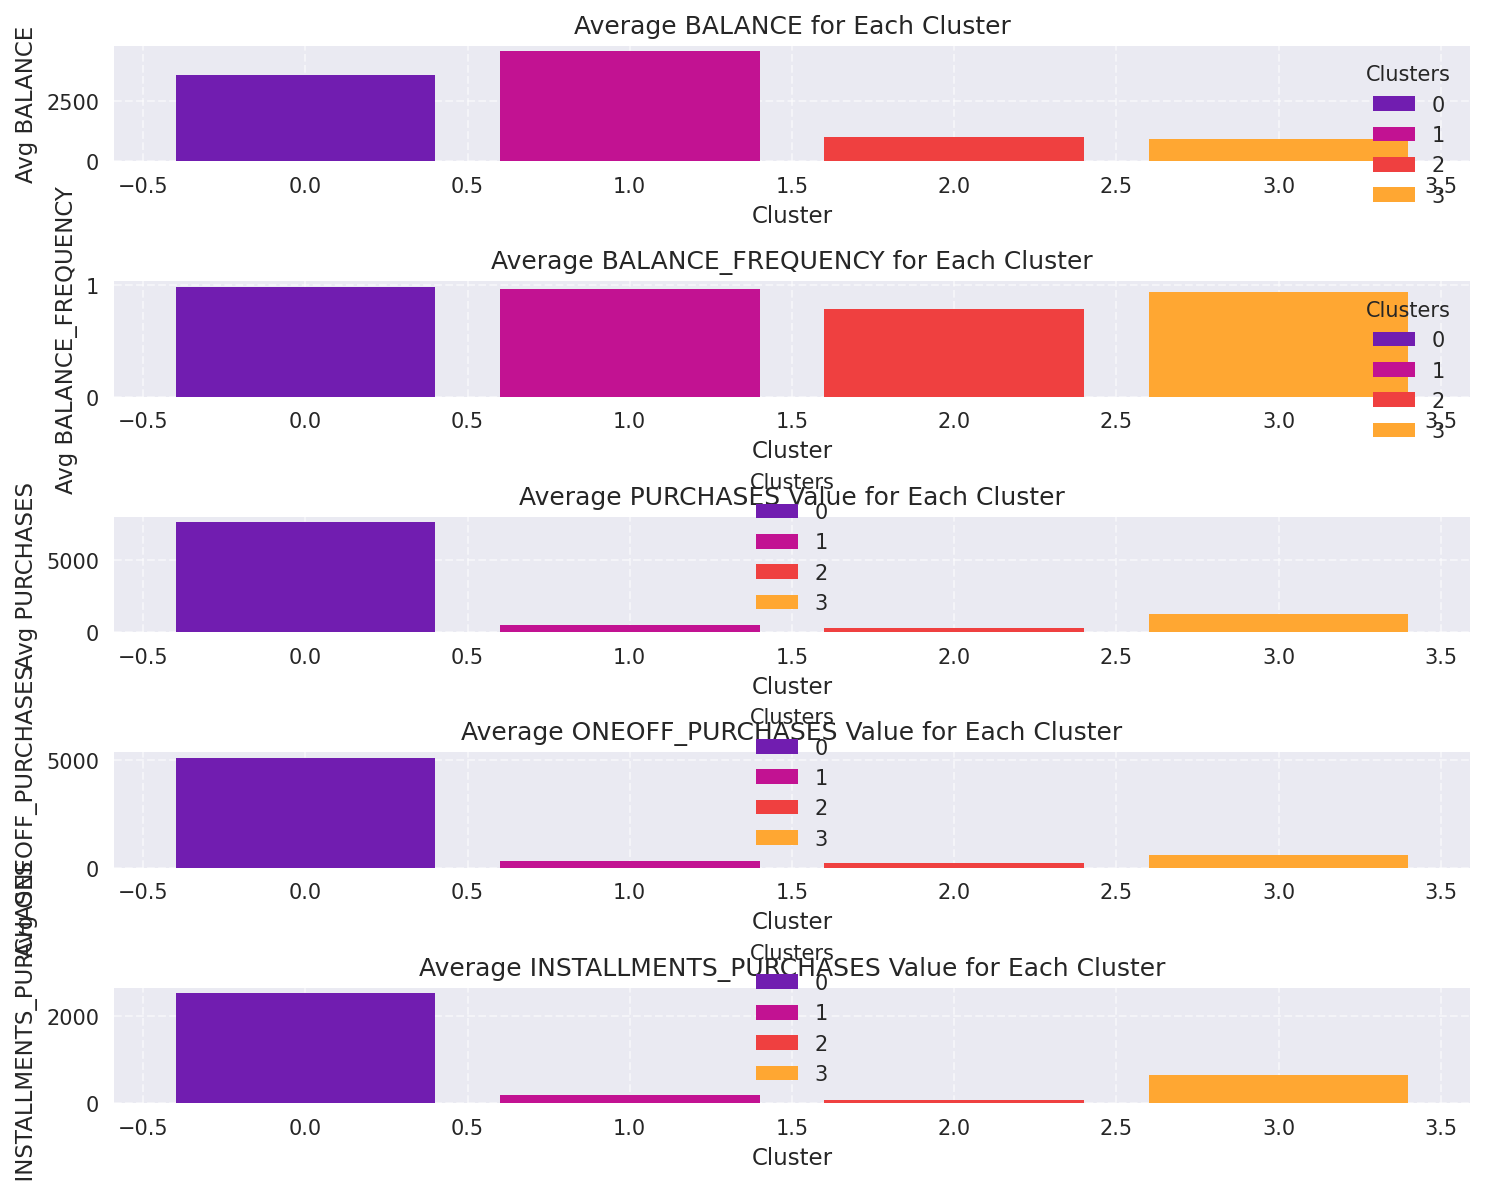

In [39]:
colors = ['#711DB0', '#C21292', '#EF4040', '#FFA732']

# Plot the average scores for each cluster
plt.figure(figsize=(10, 8),dpi=150)

# Plot Avg BALANCE
plt.subplot(5, 1, 1)
bars = plt.bar(cluster_analysis.index, cluster_analysis['BALANCE'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg BALANCE')
plt.title('Average BALANCE for Each Cluster')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg BALANCE_FREQUENCY
plt.subplot(5, 1, 2)
bars = plt.bar(cluster_analysis.index, cluster_analysis['BALANCE_FREQUENCY'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg BALANCE_FREQUENCY')
plt.title('Average BALANCE_FREQUENCY for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg PURCHASES
plt.subplot(5, 1, 3)
bars = plt.bar(cluster_analysis.index, cluster_analysis['PURCHASES'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg PURCHASES')
plt.title('Average PURCHASES Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg ONEOFF_PURCHASES
plt.subplot(5, 1, 4)
bars = plt.bar(cluster_analysis.index, cluster_analysis['ONEOFF_PURCHASES'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg ONEOFF_PURCHASES')
plt.title('Average ONEOFF_PURCHASES Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg INSTALLMENTS_PURCHASES
plt.subplot(5, 1, 5)
bars = plt.bar(cluster_analysis.index, cluster_analysis['INSTALLMENTS_PURCHASES'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg INSTALLMENTS_PURCHASES')
plt.title('Average INSTALLMENTS_PURCHASES Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

plt.tight_layout()
plt.show()

# pie chart for clusters:

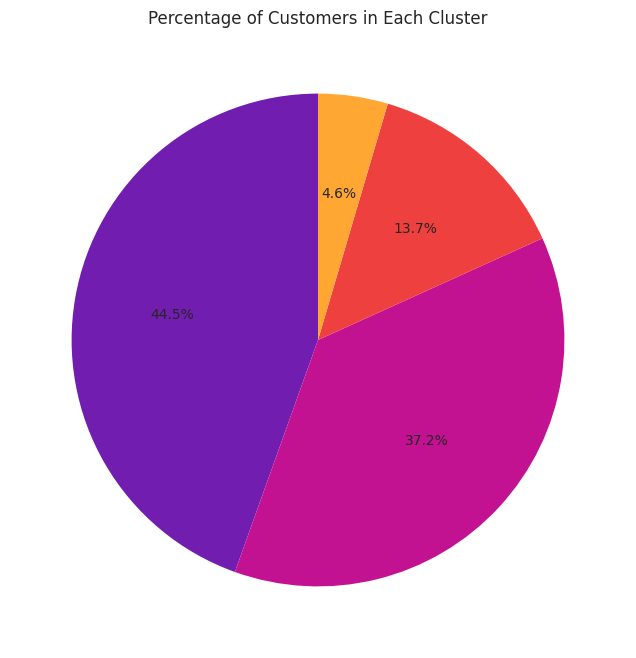

In [40]:
cluster_counts = df2_c['cluster'].value_counts()

colors = ['#711DB0', '#C21292', '#EF4040', '#FFA732']
# Calculate the total number of customers
total_customers = cluster_counts.sum()

# Calculate the percentage of customers in each cluster
percentage_customers = (cluster_counts / total_customers) * 100

# Create a pie chart
plt.figure(figsize=(8, 8),dpi=100)
plt.pie(percentage_customers, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Percentage of Customers in Each Cluster')

plt.show()

# Interpretations of clusters:

## Cluster0:

 This cluster has a relatively high average BALANCE and a highest BALANCE_FREQUENCY, suggesting that these customers regularly use their accounts and maintain a high BALANCE. They also have the highest average PURCHASES and ONEOFF_PURCHASES, which implies they make significant and frequent transactions, possibly indicating a group of high-spending customers. The high installment PURCHASES suggest they also utilize installment plans..


## Cluster1:

This cluster has the highest BALANCE and relatively high BALANCE_FREQUENCY, also, the value of PURCHASES and ONEOFF_PURCHASES rank third among the four existing clusters. INSTALLMENTS_PURCHASES are moderate in this cluster, not too much and not too little. And this shows that the customers of this cluster also use installment purchases on average..

## Cluster2:

The customers of this cluster have the low average BALANCE and the lowest BALANCE_FREQUENCY, also the customers of this cluster have the lowest amount of PURCHASES, ONEOFF_PURCHASES and  INSTALLMENTS_PURCHASES. This could represent a group that uses their credit cards infrequently and for smaller amounts, indicating that they may be more conservative in their credit card use or have lower credit limits..

## Cluster3:

This cluster has a lowest average BALANCE compared to other clusters. At the same time, it has a high BALANCE_FREQUENCY(0.93).
The amount of PURCHASES and ONEOFF_PURCHASES in this cluster ranks second.It is interesting to note that the amount of  INSTALLMENTS_PURCHASES by the customers of this cluster is also in the second place..

In [41]:
#kmeans=KMeans(n_clusters=4).fit(df2)
#centroids=kmeans.cluster_centers_
#root=tk.Tk()
#canvas1=tk.Canvas(root, width=100 , height=100)
#canvas1.pack()

#label1=tk.Label(root , text=centroids , justify='center')
#canvas1.create_window(70,50, window=label1)
#figure1=plt.Figure(figsize=(5,8) , dpi=100)
#ax1=figure1.add_subplot(111)
#ax1.scatter(df2['PURCHASES'], df2['ONEOFF_PURCHASES'], c=kmeans.labels_.astype(float),s=50 , alpha=0.5)
#ax1.scatter(centroids[:, 0] , centroids[:, 1] , c='red' , s=50)
#scatter1=FigureCanvasTkAgg(figure1 , root)
#scatter1.get_tk_widget().pack(side=tk.LEFT ,fill=tk.BOTH)
#root.mainloop()

In [42]:
#root=tk.Tk()
#canvas1=tk.Canvas(root, width=400 , height=300 , relief='raised')
#canvas1.pack()
#label1=tk.Label(root , text='k_means clustering')
#label1.config(font=('helvetica', 14))
#canvas1.create_window(200,25, window=label1)
#label2=tk.Label(root , text='Type Number of clusters:')
#label2.config(font=('helvetica', 8))
#canvas1.create_window(200,120, window=label2)

#entry1=tk.Entry(root)
#canvas1.create_window(200 , 140 , window= entry1)

#def getKMeans():
#    global df2
#    global numberOfClusters
#    numberOfCluster=int (entry1.get())
#    kmeans=KMeans(n_Cluster=numberOfCluster).fit(df1)
#    centroids=kmeans.Cluster_Center_
#    label3=tk.label(root , text=centroids)
#    canvas1.create_window(200, 250 , window=label3)
#    figure1=plt.Figure(figsize=(4,3), dpi=100)
#    ax1=figure1.add_subplot(111)
#    ax1.scatter(df2['PURCHASES'], df2['cluster'], c=kmeans.labels_.astype(float),s=50 , alpha=0.5)
#    ax1.scatter(centroids[:, 0] , centroids[:, 1] , c='red' , s=50)
#    scatter1=FigureCanvasTkAgg(figure1 , root)
#    scatter1.get_tk_widget().pack(side=tk.LEFT ,fill=tk.BOTH)
#    processButton=tk.Button(text='process k_Means' , command=getKMeans , bg='brown', fg='white' , font=('helvetica', 10 , 'bold'))
#    canvas1.create_window(200,170 , window=processButton) 
    
#    root.mainloop()
    

## Agglomerative Algorithm:

Agglomerative clustering uses a bottom-up approach, where in each data point starts in its own cluster. These clusters are then joined greedily, by taking the two most similar clusters together and merging them.  

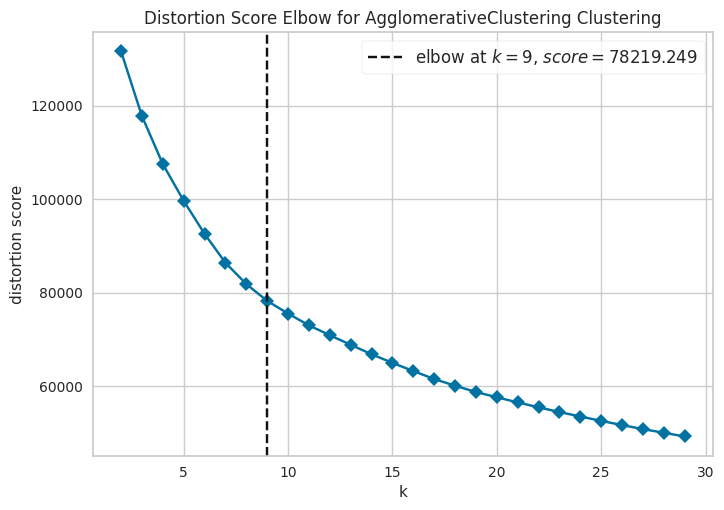

<Axes: title={'center': 'Distortion Score Elbow for AgglomerativeClustering Clustering'}, xlabel='k', ylabel='distortion score'>

In [43]:
# Import ElbowVisualizer
from sklearn.cluster import AgglomerativeClustering
from yellowbrick.cluster import KElbowVisualizer
model = AgglomerativeClustering()
# k is range of number of clusters.
visualizer = KElbowVisualizer(model, k=(2,30), timings=False)
# Fit data to visualizer
visualizer.fit(Scaled_features)
# Finalize and render figure
visualizer.show()

The output plot shows that the best number of clusters we can get out of our dataset is 9.
👇

In [44]:
#instantiate the Agglomerative class, using optimal number of clusters
clt = AgglomerativeClustering(linkage="complete", affinity="euclidean", n_clusters=9)
#fit Agglomerative algorithm to data
model = clt.fit(Scaled_features)

##view cluster assignments for each observation
model.labels_

array([1, 1, 1, ..., 1, 1, 1])

In [45]:
df2['cluster'] = model.labels_ 
#view updated DataFrame
dfc=pd.DataFrame(df2)
dfc

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,1
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,1
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,1
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0,1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,325.594462,48.886365,0.500000,6.0,1
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,275.861322,312.343947,0.000000,6.0,1
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0.0,5.0,1000.0,81.270775,82.418369,0.250000,6.0,1
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2.0,0.0,500.0,52.549959,55.755628,0.250000,6.0,1


we can see that how many data is in each cluster:

In [46]:
##Checking whether the value of nan exists in different columns of the new dataset
dfc.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
cluster                             0
dtype: int64

Finally we are predicting the clusters.

In [47]:
# Analyze the clusters
cluster_analysis = dfc.groupby('cluster').mean()


# Print the cluster analysis results
print(cluster_analysis)

              BALANCE  BALANCE_FREQUENCY     PURCHASES  ONEOFF_PURCHASES  \
cluster                                                                    
0         4257.001237           0.931061  22279.676667      16375.293333   
1         1476.244467           0.875357    902.426952        527.753051   
2         6674.080781           1.000000   1714.498571          0.000000   
3         4890.447425           0.948557   1368.224491        819.508563   
4        12513.404110           1.000000  45044.985000      40692.655000   
5         3446.747277           0.963636    206.582000        164.762000   
6         4010.621974           1.000000  40040.710000      24543.520000   
7         6447.304067           0.978610  12018.568824       2478.908824   
8         3820.419855           0.977273  29392.001250      26646.131250   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
cluster                                                              
0                   590

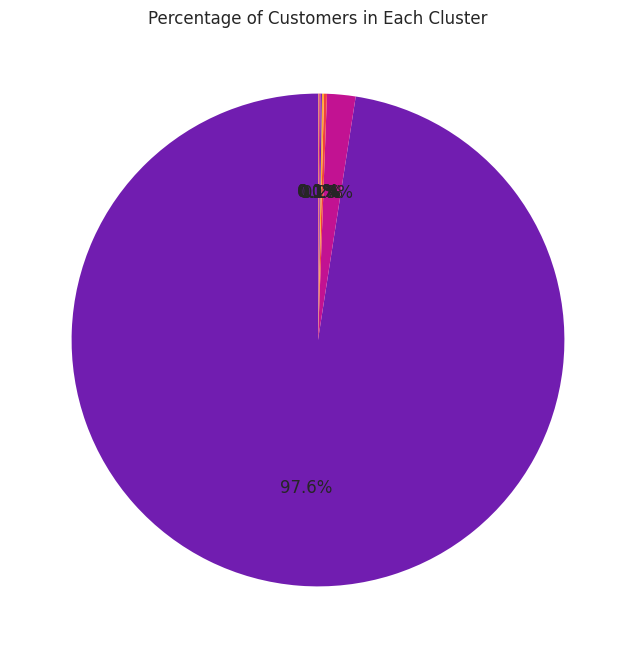

In [48]:
cluster_counts = dfc['cluster'].value_counts()

colors = ['#711DB0', '#C21292', '#EF4040', '#FFA732']
# Calculate the total number of customers
total_customers = cluster_counts.sum()

# Calculate the percentage of customers in each cluster
percentage_customers = (cluster_counts / total_customers) * 100

# Create a pie chart
plt.figure(figsize=(8, 8),dpi=100)
plt.pie(percentage_customers, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Percentage of Customers in Each Cluster')

plt.show()

1.In the above picture, 9 clusters are displayed with the percentages assigned to each of them..It is clear that the number of clusters compared to the kmean method has increased from 4 clusters to 9 clusters.

2.The remarkable thing is that a very large percentage of the data are placed in only one cluster..

# MeanShift Algorithm:

In [49]:
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.datasets import make_blobs

In [50]:
centers = [[1, 1], [-1, -1], [1, -1]]
Scaled_features, _ = make_blobs(n_samples=8948, centers=centers, cluster_std=0.6)

In [51]:
# The following bandwidth can be automatically detected using
bandwidth = estimate_bandwidth(Scaled_features, quantile=0.2, n_samples=8948)

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms.fit(Scaled_features)
labels = ms.labels_
cluster_centers = ms.cluster_centers_

labels_unique = np.unique(labels)
n_clusters_ = len(labels_unique)

print("number of estimated clusters : %d" % n_clusters_)

number of estimated clusters : 3


In [52]:
 ms.labels_

array([0, 2, 0, ..., 1, 2, 0])

In [53]:
#view cluster assignments for each observation(in dataframe form)
ms.labels=pd.DataFrame(ms.labels_)
ms.labels

,0
0,0
1,2
2,0
3,1
4,0
...,...
8943,1
8944,0
8945,1
8946,2


In [54]:
 #Checking whether the value of nan exists in cluster column of the new dataset
ms.labels.isna().sum()

0    0
dtype: int64

In [55]:
df2['cluster'] = ms.labels_ 
#view updated DataFrame
dfm=pd.DataFrame(df2)
dfm

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,0
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,2
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,0
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0,1
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,325.594462,48.886365,0.500000,6.0,1
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,275.861322,312.343947,0.000000,6.0,0
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0.0,5.0,1000.0,81.270775,82.418369,0.250000,6.0,1
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2.0,0.0,500.0,52.549959,55.755628,0.250000,6.0,2


In [56]:
# Analyze the clusters
cluster_analysis = dfm.groupby('cluster').mean()


# Print the cluster analysis results
print(cluster_analysis)

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
cluster                                                                  
0        1530.571672           0.877342   963.717097        546.673054   
1        1581.186179           0.874917  1075.352454        656.621683   
2        1577.545452           0.879556   963.517356        574.271223   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
cluster                                                              
0                    417.624312    983.347798             0.487963   
1                    418.845991    971.055440             0.493347   
2                    389.452647    967.114927             0.489701   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
cluster                                                                 
0                          0.192196                          0.367414   
1                          0.207128                        

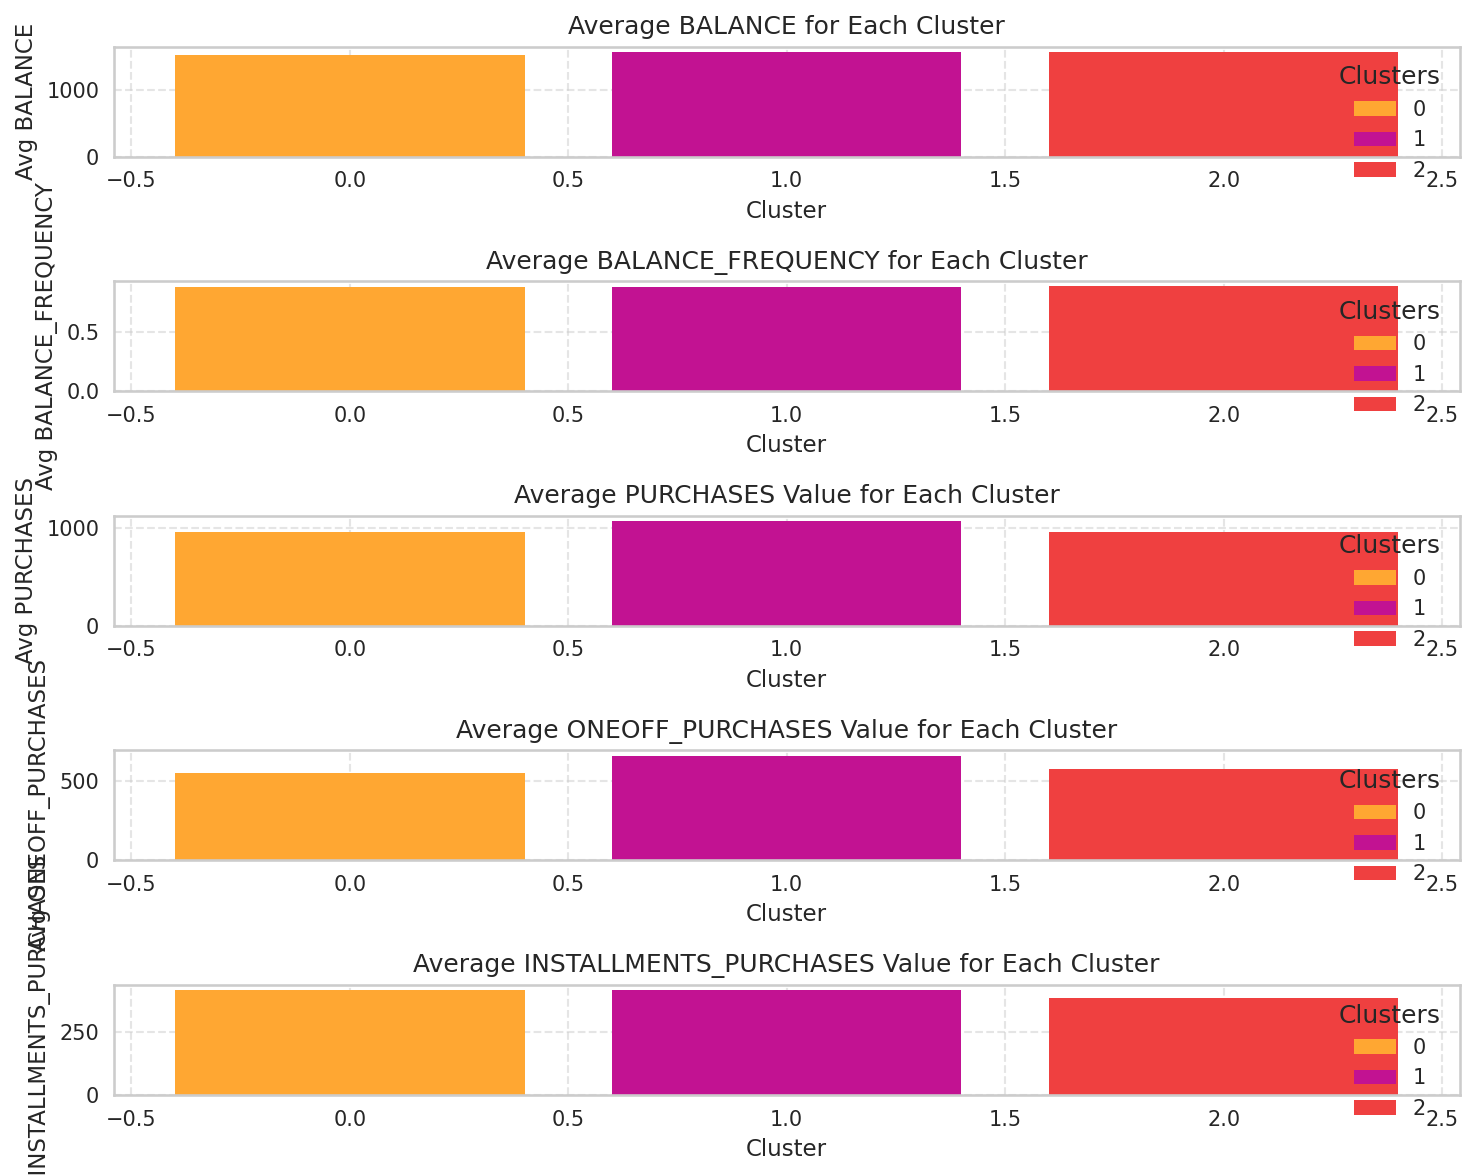

In [57]:
colors = ['#FFA732', '#C21292', '#EF4040','#711DB0']

# Plot the average scores for each cluster
plt.figure(figsize=(10, 8),dpi=150)

# Plot Avg BALANCE
plt.subplot(5, 1, 1)
bars = plt.bar(cluster_analysis.index, cluster_analysis['BALANCE'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg BALANCE')
plt.title('Average BALANCE for Each Cluster')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg BALANCE_FREQUENCY
plt.subplot(5, 1, 2)
bars = plt.bar(cluster_analysis.index, cluster_analysis['BALANCE_FREQUENCY'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg BALANCE_FREQUENCY')
plt.title('Average BALANCE_FREQUENCY for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg PURCHASES
plt.subplot(5, 1, 3)
bars = plt.bar(cluster_analysis.index, cluster_analysis['PURCHASES'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg PURCHASES')
plt.title('Average PURCHASES Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg ONEOFF_PURCHASES
plt.subplot(5, 1, 4)
bars = plt.bar(cluster_analysis.index, cluster_analysis['ONEOFF_PURCHASES'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg ONEOFF_PURCHASES')
plt.title('Average ONEOFF_PURCHASES Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg INSTALLMENTS_PURCHASES
plt.subplot(5, 1, 5)
bars = plt.bar(cluster_analysis.index, cluster_analysis['INSTALLMENTS_PURCHASES'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg INSTALLMENTS_PURCHASES')
plt.title('Average INSTALLMENTS_PURCHASES Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

plt.tight_layout()
plt.show()

<h3 align="left"><font color='#FFA732'>💡 Note:</font></h3>

According to the explanations given for the k_mean algorithm and the interpretation of each cluster, in this section, each cluster can be similarly analyzed according to the desired features..

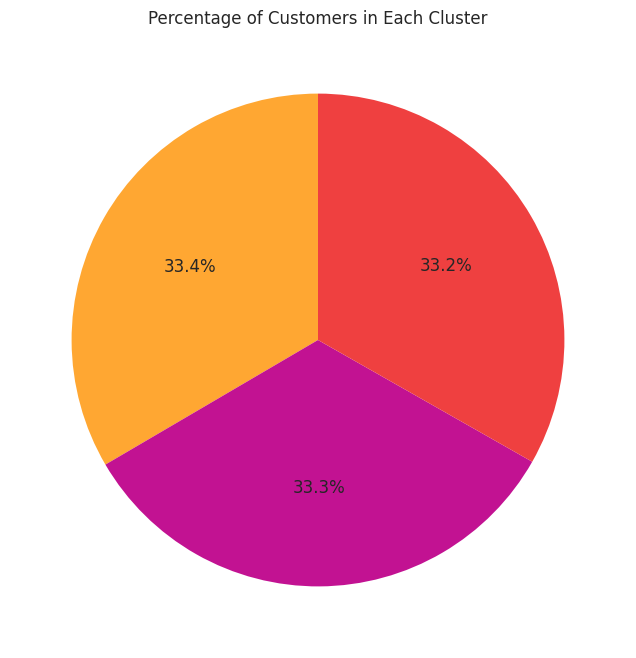

In [58]:
cluster_counts = dfm['cluster'].value_counts()

colors = ['#FFA732', '#C21292', '#EF4040','#711DB0']
# Calculate the total number of customers
total_customers = cluster_counts.sum()

# Calculate the percentage of customers in each cluster
percentage_customers = (cluster_counts / total_customers) * 100

# Create a pie chart
plt.figure(figsize=(8, 8),dpi=100)
plt.pie(percentage_customers, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Percentage of Customers in Each Cluster')

plt.show()

<h3 align="left"><font color='#C21292'>💡 Note:</font></h3>

According to the pie chart above, it can be seen that in this method, the distribution of data in three clusters is almost uniform..

# What is DBSCAN?

1.Density Based Spatial Clustering of Applications with Noise (abbreviated as DBSCAN) is a density-based unsupervised clustering algorithm. In DBSCAN, clusters are formed from dense regions and separated by regions of no or low densities.

2.DBSCAN computes nearest neighbor graphs and creates arbitrary-shaped clusters in datasets (which may contain noise or outliers) as opposed to k-means clustering, which typically generates spherical-shaped clusters.

3.Unlike k-means clustering, DBSCAN does not require specifying the number of clusters initially. However, DBSCAN requires two parameters viz. the radius of neighborhoods for a given data point p (eps or ε) and the minimum number of data points in a given ε-neighborhood to form clusters ..

4.DBSCAN is also useful for clustering non-linear datasets.

## Compute required parameters for DBSCAN clustering

1.DBSCAN requires ε and minPts parameters for clustering. The minPts parameter is easy to set. The minPts should be 4 for two-dimensional dataset. For multidimensional dataset, minPts should be 2 * number of dimensions. For example, if your dataset has 6 features, set minPts = 12. Sometimes, domain expertise is also required to set a minPts parameter.

2.Another question is what optimal value should be used for the ε parameter. The ε parameter is difficult to set and depends on the distance function. Sometimes, domain expertise is also required to set a ε parameter. The ε should be as small as possible.

3.To determine the optimal ε parameter, I will compute the k-nearest neighbor (kNN) distances (average distance of every data point to its k-nearest neighbors) of an input dataset using the k-nearest neighbor method (unsupervised nearest neighbors learning). For finding the k-nearest neighbor, I will use the sklearn.neighbors.NearestNeighbors function.

In [59]:
from sklearn.neighbors import NearestNeighbors
# n_neighbors = 17*2=34 as kneighbors function returns distance of point to itself (i.e. first column will be zeros) 
nbrs = NearestNeighbors(n_neighbors = 34).fit(Scaled_features)
# Find the k-neighbors of a point
neigh_dist, neigh_ind = nbrs.kneighbors(Scaled_features)
# sort the neighbor distances (lengths to points) in ascending order
# axis = 0 represents sort along first axis i.e. sort along row
sort_neigh_dist = np.sort(neigh_dist, axis = 0)

NearestNeighbors function requires n_neighbors (number of neighbors) parameter, which can be same as the minPts value.

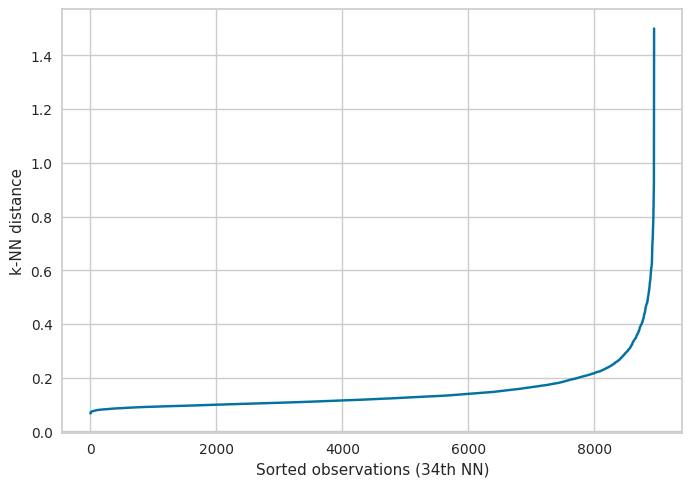

In [60]:
k_dist = sort_neigh_dist[:, 33]
plt.plot(k_dist)
plt.ylabel("k-NN distance")
plt.xlabel("Sorted observations (34th NN)")
plt.show()

1.In the k-NN distance plot, you should look for the “knee” or “elbow” point (a threshold value where you see a sharp change) of the curve to find the optimal value of ε.


2.Identifying the exact knee point could be difficult visually. In the below plot, the knee point can occur at any point between 1000 to 3000 i.e. the points below knee point belong to a cluster, and points above the knee point are noise or outliers (noise points will have higher kNN distance). You should run DBSCAN based on different values of ε (between 1000 and 3000) to find the best ε that gives the best clustering.

In [61]:
from kneed import KneeLocator
kneedle = KneeLocator(x = range(1, len(neigh_dist)+1), y = k_dist, S = 1.0, 
                      curve = "concave", direction = "increasing", online=True)

# get the estimate of knee point
print(kneedle.knee_y)

0.612788801577711


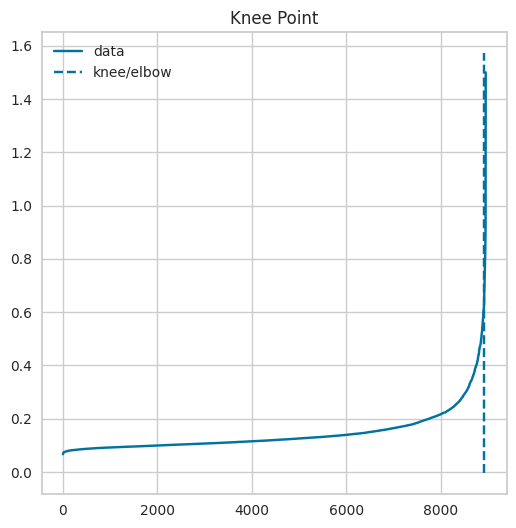

In [62]:
kneedle.plot_knee()
plt.show()

In [63]:
from sklearn.cluster import DBSCAN
clusters = DBSCAN(eps = 0.58, min_samples = 34).fit(Scaled_features)
# get cluster labels
clusters.labels_

array([0, 0, 0, ..., 0, 0, 0])

In [64]:
# check unique clusters
set(clusters.labels_)
# -1 value represents noisy points could not assigned to any cluster

{-1, 0}

1.According to the above commands, it can be seen that we cannot cluster the data using the DBSCAN algorithm.In fact, it has put all the data in one cluster.

2.Below are some of the features of this method:

## DBSCAN limitations

1.DBSCAN is computationally expensive (less scalable) and more complicated clustering method as compared to simple k-means clustering

2.DBSCAN is sensitive to input parameters, and it is hard to set accurate input parameters.

3.DBSCAN depends on a single value of ε for all clusters, and therefore, clusters with variable densities may not be correctly identified by DBSCAN.

4.DBSCAN is a time-consuming algorithm for clustering.

## Gaussian Mixture Models (GMMs):

The Gaussian Mixture Model (GMM) is a probabilistic model used for clustering and density estimation. It assumes that the data is generated from a mixture of several Gaussian distributions, each representing a distinct cluster.

Text(0.5, 0, 'Number Of Component')

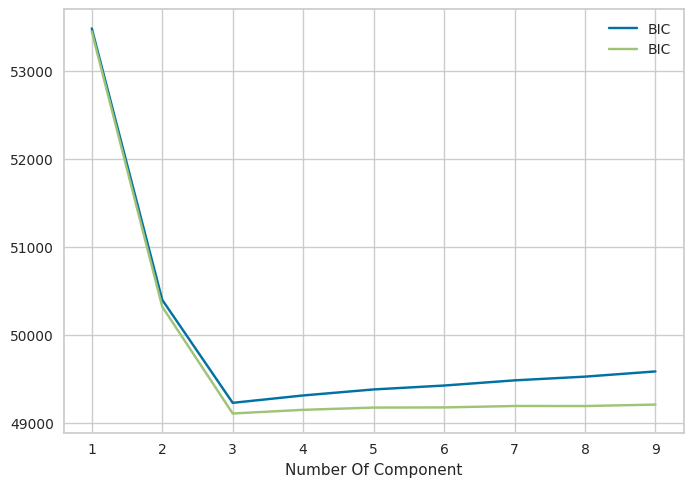

In [65]:
#Prepare
n_conponent = np.arange(1,10)

#Create GGM Model
models = [GaussianMixture(n_components = n,
                          random_state=42).fit(Scaled_features) for n in n_conponent]
#Plot
plt.plot(n_conponent,
         [m.bic(Scaled_features) for m in models],
         label = 'BIC')
plt.plot(n_conponent,
         [m.aic(Scaled_features) for m in models],
         label = 'BIC')
plt.legend()
plt.xlabel("Number Of Component")

## Create GM Model And Predict:

In [66]:
# create GM Models
model = GaussianMixture(n_components=3, random_state=42).fit(Scaled_features)
##view cluster assignments for each observation
model.predict(Scaled_features)

array([1, 2, 1, ..., 0, 2, 1])

In [67]:
#adding new column(cluster) to dataset
df2['cluster'] = model.predict(Scaled_features)

In [68]:
#new dataset
dfg=pd.DataFrame(df2)
dfg

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0.0,2.0,1000.0,201.802084,139.509787,0.000000,12.0,1
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4.0,0.0,7000.0,4103.032597,1072.340217,0.222222,12.0,2
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0.0,12.0,7500.0,622.066742,627.284787,0.000000,12.0,1
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1.0,1.0,7500.0,0.000000,312.343947,0.000000,12.0,0
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0.0,1.0,1200.0,678.334763,244.791237,0.000000,12.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,325.594462,48.886365,0.500000,6.0,0
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0.0,6.0,1000.0,275.861322,312.343947,0.000000,6.0,1
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0.0,5.0,1000.0,81.270775,82.418369,0.250000,6.0,0
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2.0,0.0,500.0,52.549959,55.755628,0.250000,6.0,2


In [69]:
##Checking whether the value of nan exists in different columns of the new dataset
dfg.isna().sum()

BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
cluster                             0
dtype: int64

In [70]:
# Analyze the clusters
cluster_analysis = dfg.groupby('cluster').mean()


# Print the cluster analysis results
print(cluster_analysis)

             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
cluster                                                                  
0        1582.642612           0.875915  1075.161183        656.519012   
1        1527.568629           0.876727   961.004748        543.966261   
2        1579.240762           0.879171   966.674043        577.348829   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
cluster                                                              
0                    418.757661    973.429638             0.493178   
1                    417.617005    980.524244             0.488488   
2                    389.531866    967.528210             0.489359   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
cluster                                                                 
0                          0.206803                          0.364756   
1                          0.191979                        

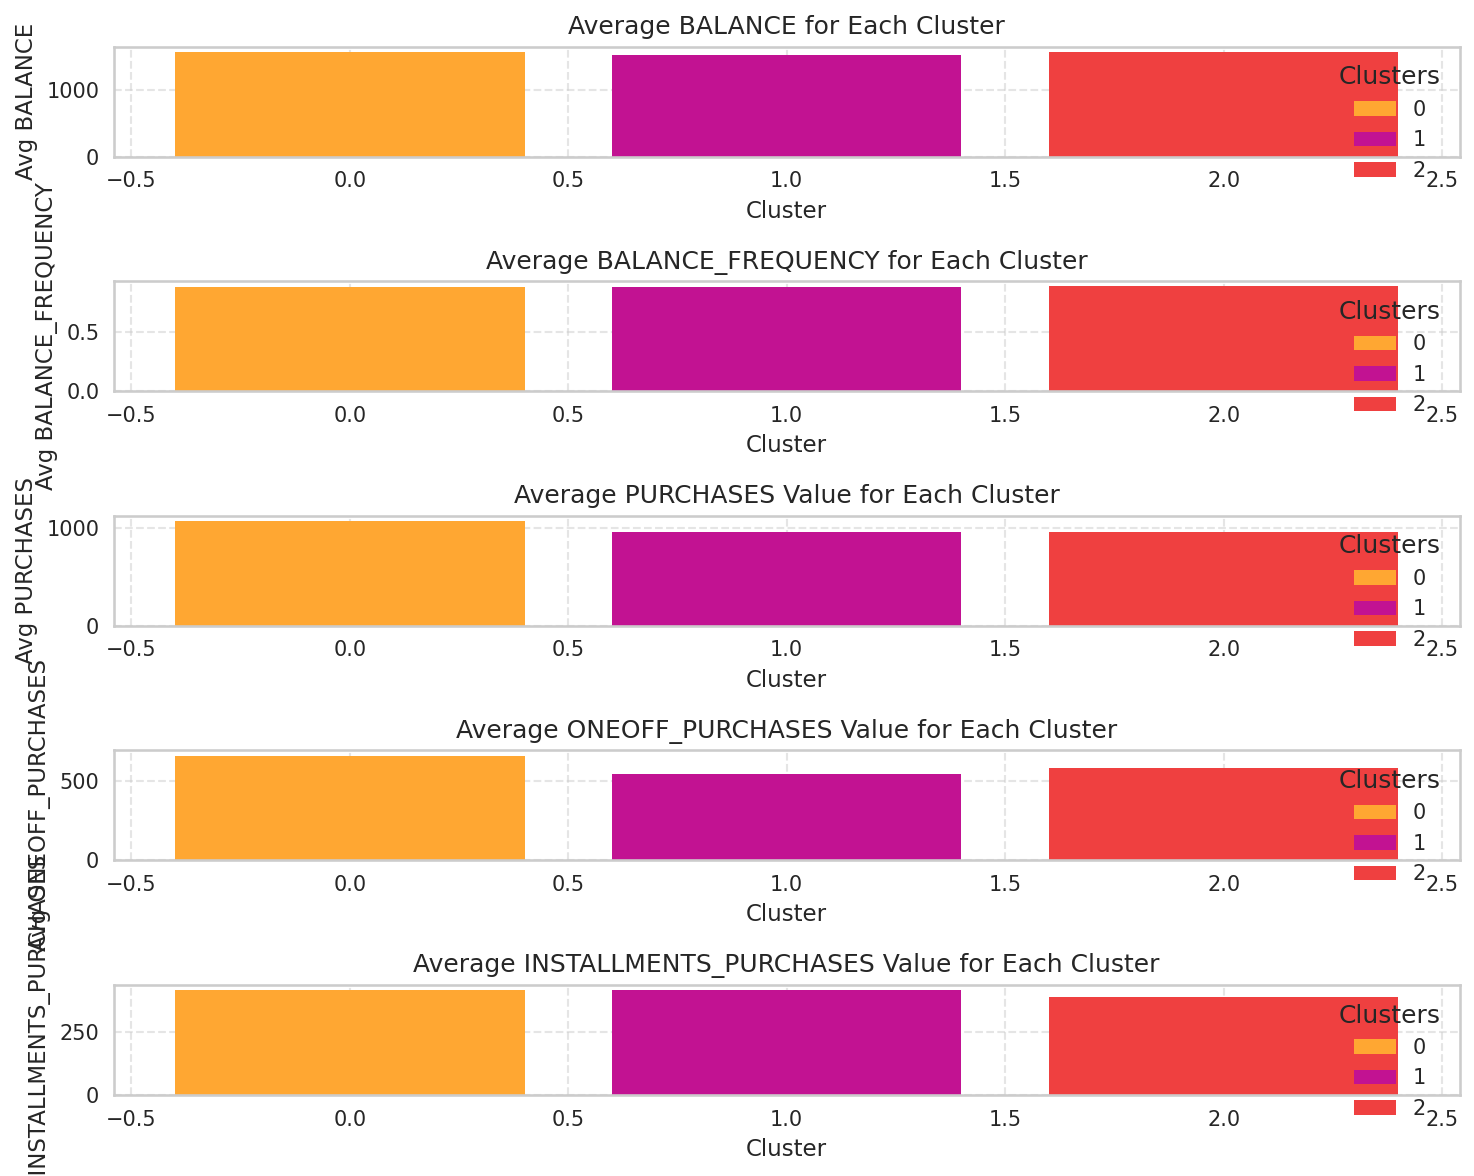

In [71]:
colors = ['#FFA732', '#C21292', '#EF4040','#711DB0']

# Plot the average scores for each cluster
plt.figure(figsize=(10, 8),dpi=150)

# Plot Avg BALANCE
plt.subplot(5, 1, 1)
bars = plt.bar(cluster_analysis.index, cluster_analysis['BALANCE'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg BALANCE')
plt.title('Average BALANCE for Each Cluster')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg BALANCE_FREQUENCY
plt.subplot(5, 1, 2)
bars = plt.bar(cluster_analysis.index, cluster_analysis['BALANCE_FREQUENCY'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg BALANCE_FREQUENCY')
plt.title('Average BALANCE_FREQUENCY for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg PURCHASES
plt.subplot(5, 1, 3)
bars = plt.bar(cluster_analysis.index, cluster_analysis['PURCHASES'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg PURCHASES')
plt.title('Average PURCHASES Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg ONEOFF_PURCHASES
plt.subplot(5, 1, 4)
bars = plt.bar(cluster_analysis.index, cluster_analysis['ONEOFF_PURCHASES'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg ONEOFF_PURCHASES')
plt.title('Average ONEOFF_PURCHASES Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

# Plot Avg INSTALLMENTS_PURCHASES
plt.subplot(5, 1, 5)
bars = plt.bar(cluster_analysis.index, cluster_analysis['INSTALLMENTS_PURCHASES'], color=colors)
plt.xlabel('Cluster')
plt.ylabel('Avg INSTALLMENTS_PURCHASES')
plt.title('Average INSTALLMENTS_PURCHASES Value for Each Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bars, cluster_analysis.index, title='Clusters')

plt.tight_layout()
plt.show()

<h3 align="left"><font color='#E83500'>💡 Note:</font></h3>

According to the explanations given for the k_mean algorithm and the interpretation of each cluster, in this section, each cluster can be similarly analyzed according to the desired features..

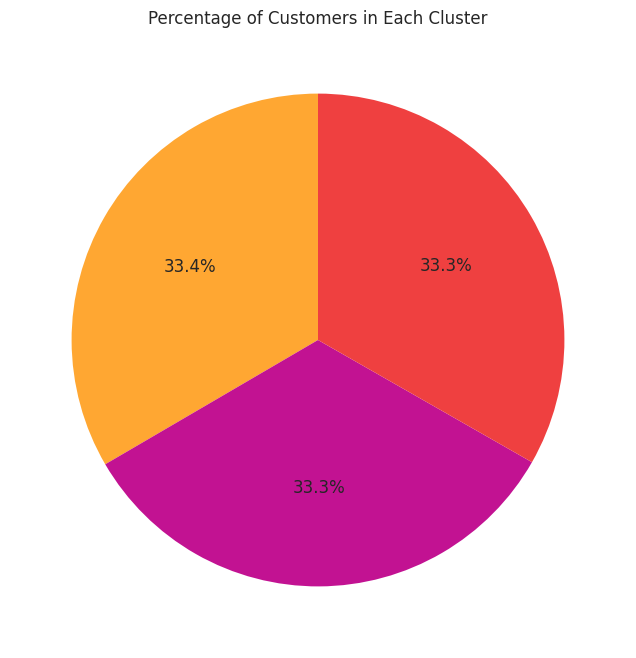

In [72]:
cluster_counts = dfg['cluster'].value_counts()

colors = ['#FFA732', '#C21292', '#EF4040','#711DB0']
# Calculate the total number of customers
total_customers = cluster_counts.sum()

# Calculate the percentage of customers in each cluster
percentage_customers = (cluster_counts / total_customers) * 100

# Create a pie chart
plt.figure(figsize=(8, 8),dpi=100)
plt.pie(percentage_customers, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Percentage of Customers in Each Cluster')

plt.show()

# Conclusion:

1.A good clustering method requirements are:The ability to discover some or all of the hidden clusters. Within-cluster similarity and between-cluster dissimilarity. Ability to deal with various types of attributes..

2.Both MeanShift and GMM algorithms have almost the same percentage of similar data in different clusters..

3.In this project, it was observed that DBSCAN and Agglomirative algorithms did not perform well in data clustering. GMM, MeanShift and K_mean algorithms put the data in different clusters in a better way. And they were better able to find connections between different data and find similarities between them from different points of view and put them in a cluster.

## Sheyda Ayati

# #15